# CS552J – Data Mining with Deep Learning: Assessment 2
## Extracting Insights from Counselling Dialogue

**Module:** CS552J – Data Mining with Deep Learning  
**Dataset:** AnnoMI – Annotated Motivational Interviewing Dialogues  

---

### Overview

This notebook presents a complete NLP pipeline applied to the AnnoMI dataset — a corpus of counselling dialogues annotated with session quality labels (`high`/`low`) and speaker behaviour codes derived from established Motivational Interviewing (MI) coding schemes. The work is organised as follows:

- **Task 1** — Conceptual grounding: preprocessing, feature extraction, deep learning approaches, and evaluation methodology.
- **Task 2** — Empirical pipeline: exploratory data analysis, SBERT-based extractive summarisation with behavioural discourse analysis, and a comparative evaluation of a tuned classical classifier (Logistic Regression) against a fine-tuned transformer (RoBERTa-base).

Motivational Interviewing is a client-centred counselling style aimed at eliciting intrinsic motivation for behavioural change (Miller & Rollnick, 2013). Automated behaviour classification from dialogue could substantially reduce the burden of expert annotation and enable scalable therapist feedback tools.

---
## Task 1: Description of Data and Methods

### 1.1 Basic Preprocessing Steps

Raw counselling dialogue presents several preprocessing challenges that differ from standard NLP corpora such as news articles:

**Tokenisation** splits raw text into discrete units. Conversational data contains disfluencies, contractions (`I'm`, `you've`), and informal punctuation that whitespace splitting handles poorly. NLTK's `word_tokenize` or Hugging Face's `AutoTokenizer` manage these edge cases more robustly. For transformer-based models, WordPiece or Byte-Pair Encoding (BPE) sub-word tokenisers are essential: they handle out-of-vocabulary tokens — such as domain-specific MI terms — by decomposing them into known sub-word units.

**Text normalisation** encompasses lowercasing, removing extraneous whitespace, and standardising punctuation. In clinical dialogue, filler words (`um`, `uh`) may carry pragmatic meaning (e.g., signalling hesitation or rapport-building), so domain knowledge should inform whether they are retained or discarded.

**Stop word removal** eliminates high-frequency function words that contribute little semantic information in bag-of-words models. However, negations (`not`, `never`) are semantically significant for tasks like change-talk detection and should be preserved.

**Lemmatisation** reduces inflected forms to their canonical root using lexical knowledge (e.g., WordNet), and is preferred over stemming for clinical text since it preserves genuine morphological relationships rather than applying heuristic suffix-stripping.

**Deduplication** is a critical and often overlooked step for dialogue corpora. The AnnoMI dataset contains substantial numbers of duplicate utterances (e.g., back-channel acknowledgements such as *"Mm-hmm"* and *"Yeah"* occurring hundreds of times), predominantly coded as `other`. Retaining these would inflate the majority class and bias classifiers toward surface-level form rather than semantic content (Wu et al., 2023).

**Turn segmentation and speaker role preservation**: dialogue structure — specifically the alternation between therapist and client turns — carries information beyond the text content of individual utterances. Speaker role should be preserved as a feature throughout all analyses.

---

### 1.2 Feature Extraction Methods

Classical feature extraction provides interpretable, hypothesis-driven insights prior to deep modelling:

**Lexical/surface features:** Utterance length in tokens and characters, type-token ratio (TTR) as a measure of lexical diversity, average word length, and punctuation ratios (e.g., question marks per utterance) capture surface-level communicative patterns that may systematically differ by speaker role or session quality.

**Part-of-Speech (POS) tagging** identifies grammatical roles per token. MI research predicts that therapist `question` utterances will contain more interrogative pronouns and auxiliary verbs, while `reflection` utterances will contain more second-person pronouns and hedging adverbs.

**TF-IDF (Term Frequency–Inverse Document Frequency)** re-weights term counts by cross-document discriminativeness, making it more informative than raw bag-of-words for comparing behaviour categories. Sublinear TF scaling (`log(1+TF)`) is recommended to reduce the dominance of high-frequency terms.

**Domain lexicons:** MI-specific word lists for change-talk and sustain-talk vocabulary provide theory-grounded discriminative features, directly operationalising constructs measured by established MI coding instruments such as MITI (Moyers et al., 2010).

---

### 1.3 Deep Learning Approaches and Trade-offs

**Recurrent architectures (LSTM/GRU):** Sequential models process text token-by-token, maintaining hidden state to model contextual dependencies. They were the dominant NLP paradigm until ~2018 but are constrained by their sequential computation (not parallelisable) and difficulty modelling long-range dependencies.

**Transformer-based pre-trained language models:** The transformer architecture (Vaswani et al., 2017) uses self-attention to simultaneously compute pairwise relationships between all tokens, enabling full bidirectional context modelling. BERT (Devlin et al., 2019) and its derivatives such as **RoBERTa** (Liu et al., 2019) — which removes the next-sentence prediction objective, uses larger batches, and trains longer — have become the dominant approach for text classification. For this task, we fine-tune `roberta-base`, adding a classification head over the `[CLS]` token representation. Transfer learning from large-scale pre-training on diverse text corpora (BookCorpus, English Wikipedia, CC-News, OpenWebText, Stories) provides the model with rich linguistic knowledge that generalises to the specialised counselling dialogue domain.

**Summarisation approaches:** *Extractive* methods (TF-IDF ranking, TextRank, SBERT-based clustering) select existing sentences as the summary, guaranteeing faithfulness to the source. *Abstractive* methods (BART, T5, GPT-variants) generate novel summary text, risking hallucination of clinically inaccurate content. For clinical dialogue analysis, extractive summarisation is methodologically preferable because: (1) it is faithful by construction; (2) its outputs are directly verifiable against the source; and (3) it does not require large training data for reliable performance.

**Key trade-offs:**
- *Dataset size:* RoBERTa fine-tuning requires care on small datasets (~4,800 utterances). Strategies include: learning rate warmup, small number of epochs (2–4), early stopping, and frozen early encoder layers.
- *Interpretability:* Logistic Regression with TF-IDF offers coefficient-level interpretability crucial in clinical settings. Transformer attention weights provide some post-hoc interpretability but are not reliable explanations.
- *Computational cost:* Transformer fine-tuning requires GPU acceleration; inference is slower than classical models.
- *Class imbalance:* Skewed class distributions (`other` is dominant) affect all model types and must be addressed via class weighting or stratified sampling.

---

### 1.4 Evaluation Methodology

**Classification metrics:** Accuracy is misleading under class imbalance. We report **Precision**, **Recall**, and **F1-score** per class, with **macro-averaged F1** as the primary metric (treats all classes equally regardless of support). **Weighted F1** is reported as a secondary metric accounting for class frequency.

**Confusion matrices** provide a visual breakdown of true/false positives and negatives, enabling identification of systematic error patterns (e.g., whether `other` is systematically confused with `reflection`).

**Subset analysis:** Reporting performance across data subsets (session quality, topic) reveals whether a model's average performance masks poor generalisation in specific conditions.

**For summarisation evaluation:** ROUGE metrics (ROUGE-1, ROUGE-2, ROUGE-L) measure n-gram and subsequence overlap between generated and reference summaries. For semantic faithfulness, BERTScore computes token-level similarity using contextual embeddings, capturing paraphrase relationships that n-gram metrics miss.

**Cross-validation:** 5-fold stratified cross-validation on the training set provides reliable performance estimates and variance measurement, mitigating the risk of evaluation results being driven by a single favourable random split.

---
## Task 2: Investigate, Model, and Report on Insights

### Environment Setup

In [53]:
# ── Install dependencies (run once; comment out after first execution) ──────
# !pip install sentence-transformers transformers torch scikit-learn \
#              matplotlib seaborn pandas numpy scipy --quiet
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [54]:
# ─── Standard Library ────────────────────────────────────────────────────────
import warnings, re, os, time
warnings.filterwarnings('ignore')

# ─── Data Manipulation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

# ─── NLP / Text Processing ───────────────────────────────────────────────────
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# ─── Classical ML ────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from scipy.stats import mannwhitneyu, chi2_contingency

# ─── Deep Learning ───────────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sentence_transformers import SentenceTransformer

# ─── Reproducibility ─────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ All imports successful.")
print(f"  PyTorch device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

# ─── Plotting Defaults ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

PALETTE_QUALITY = {'high': '#2E86AB', 'low': '#E84855'}
PALETTE_SPEAKER = {'therapist': '#3D5A80', 'client': '#EE6C4D'}
PALETTE_BEH = {
    'reflection':      '#3D5A80',
    'question':        '#98C1D9',
    'therapist_input': '#E0FBFC',
    'other':           '#EE6C4D'
}

✓ All imports successful.
  PyTorch device: cuda
  GPU: Tesla T4


### Subtask 2.1 – Load Dataset, Deduplication, and Summary Statistics

In [55]:
# ─── Load Dataset ────────────────────────────────────────────────────────────
import pandas as pd
import os

DATA_PATH = 'dataset.csv'

if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH)
    print(f"✓ Real dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
    expected_cols = ['mi_quality', 'interlocutor', 'utterance_text',
                     'main_therapist_behaviour', 'client_talk_type']
    missing = [c for c in expected_cols if c not in df_raw.columns]
    if missing:
        print(f"⚠ Warning: Missing expected columns: {missing}")
else:
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Please upload the dataset file "
        "to the same directory as this notebook (or Google Colab environment)."
    )

print("\nColumn dtypes:")
print(df_raw.dtypes)
display(df_raw.head(4))

print("\nMI Quality Label Distribution:")
print(df_raw['mi_quality'].value_counts())

✓ Real dataset loaded: 9,699 rows × 11 columns

Column dtypes:
transcript_id                int64
mi_quality                  object
video_title                 object
video_url                   object
topic                       object
utterance_id                 int64
interlocutor                object
timestamp                   object
utterance_text              object
main_therapist_behaviour    object
client_talk_type            object
dtype: object


,transcript_id,mi_quality,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,main_therapist_behaviour,client_talk_type
0,0,high,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,0,therapist,00:00:13,Thanks for filling it out. We give this form t...,question,NaN
1,0,high,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,1,client,00:00:24,Sure.,NaN,neutral
2,0,high,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,2,therapist,00:00:25,"So, let's see. It looks that you put-- You dri...",therapist_input,NaN
3,0,high,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,3,client,00:00:34,Mm-hmm.,NaN,neutral



MI Quality Label Distribution:
mi_quality
high    8839
low      860
Name: count, dtype: int64


In [56]:
# ─── Missing Value Report ─────────────────────────────────────────────────────
print("Missing values per column:")
mv = df_raw.isnull().sum()
mv_pct = (mv / len(df_raw) * 100).round(2)
display(pd.DataFrame({'Missing Count': mv, 'Missing %': mv_pct}))

print("\nNote: main_therapist_behaviour is null for client rows (expected by design).")
print("      client_talk_type is null for therapist rows (expected by design).")

Missing values per column:


,Missing Count,Missing %
transcript_id,0,0.00
mi_quality,0,0.00
video_title,0,0.00
video_url,0,0.00
topic,0,0.00
utterance_id,0,0.00
interlocutor,0,0.00
timestamp,0,0.00
utterance_text,0,0.00
main_therapist_behaviour,4817,49.66



Note: main_therapist_behaviour is null for client rows (expected by design).
      client_talk_type is null for therapist rows (expected by design).


In [57]:
# ─── Deduplication ───────────────────────────────────────────────────────────
# The AnnoMI dataset contains many duplicate utterances, predominantly short
# back-channel acknowledgements (e.g. "Mm-hmm", "Yeah") labelled as 'other'.
# Retaining these inflates the majority class and rewards classifiers that
# learn surface form rather than semantic content (Wu et al., 2023).

# Step 1: Inspect top duplicate utterances
dup_counts = df_raw['utterance_text'].value_counts()
print("Top 20 most repeated utterances:")
print(dup_counts.head(20).to_string())

n_before = len(df_raw)
n_exact_dups = df_raw.duplicated(subset='utterance_text').sum()
print(f"\nTotal rows          : {n_before:,}")
print(f"Exact text duplicates: {n_exact_dups:,} ({n_exact_dups/n_before*100:.1f}%)")

Top 20 most repeated utterances:
utterance_text
Yeah.            694
Mm-hmm.          491
Okay.            275
Mm.              126
Right.           111
Yes.              58
Uh-huh.           50
No.               39
Sure.             38
Hmm.              32
Yeah, yeah.       30
Yeah?             23
All right.        22
Thank you.        19
Yep.              15
Oh, okay.         13
Alright.          11
Mm-hmm. Yeah.     10
Oh.                9
I don't know.      8

Total rows          : 9,699
Exact text duplicates: 2,335 (24.1%)


In [58]:
# Step 2: Apply deduplication
# We deduplicate within each (interlocutor, main_therapist_behaviour) group:
# short generic utterances in the same category are not informative duplicates.
# This mirrors the approach of Wu et al. (2023) on the AnnoMI dataset.

# Normalise text: lowercase and strip whitespace for duplicate detection only
df_raw['_text_norm'] = df_raw['utterance_text'].str.lower().str.strip()

# Deduplicate on (normalised text, interlocutor, behaviour label)
df = df_raw.drop_duplicates(
    subset=['_text_norm', 'interlocutor', 'main_therapist_behaviour'],
    keep='first'
).drop(columns=['_text_norm']).reset_index(drop=True)

n_after = len(df)
n_removed = n_before - n_after
print(f"Rows before deduplication : {n_before:,}")
print(f"Rows after deduplication  : {n_after:,}")
print(f"Rows removed              : {n_removed:,} ({n_removed/n_before*100:.1f}%)")

print("\nClass distribution after deduplication:")
print(df['main_therapist_behaviour'].value_counts(dropna=True))
print("\nClient talk type after deduplication:")
print(df['client_talk_type'].value_counts(dropna=True))
print("\nMI Quality after deduplication:")
print(df['mi_quality'].value_counts())

Rows before deduplication : 9,699
Rows after deduplication  : 7,434
Rows removed              : 2,265 (23.4%)

Class distribution after deduplication:
main_therapist_behaviour
question           1372
reflection         1292
therapist_input     614
other               513
Name: count, dtype: int64

Client talk type after deduplication:
client_talk_type
neutral    2076
change     1049
sustain     518
Name: count, dtype: int64

MI Quality after deduplication:
mi_quality
high    6730
low      704
Name: count, dtype: int64


In [59]:
# ─── Text Feature Engineering ────────────────────────────────────────────────
# A comprehensive set of lexical and structural features derived from
# utterance_text. These serve dual purposes: EDA insights and classifier inputs.

# MI-grounded lexicons (operationalising MITI coding constructs)
CHANGE_TALK_VOCAB = {
    'want', 'need', 'wish', 'hope', 'ready', 'able', 'will', 'could',
    'try', 'change', 'better', 'improve', 'stop', 'quit', 'start',
    'begin', 'consider', 'believe', 'commit', 'decide', 'plan', 'intend'
}
SUSTAIN_TALK_VOCAB = {
    "can't", 'cannot', "won't", 'never', 'hard', 'difficult',
    'impossible', 'tired', 'stuck', 'doubt', 'worry', 'afraid',
    'though', 'although', 'despite', 'but', 'however'
}
EMPATHY_VOCAB = {
    'understand', 'hear', 'feel', 'sounds', 'sense', 'imagine',
    'appreciate', 'difficult', 'challenge', 'struggle'
}
FIRST_PERSON = {'i', 'me', 'my', 'myself', 'mine'}
SECOND_PERSON = {'you', 'your', 'yourself', 'yours'}

STOP_WORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your',
    'yours','yourself','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs',
    'themselves','what','which','who','whom','this','that','these',
    'those','am','is','are','was','were','be','been','being','have',
    'has','had','having','do','does','did','doing','a','an','the',
    'and','but','if','or','because','as','until','while','of','at',
    'by','for','with','about','against','between','into','through',
    'during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then',
    'once','here','there','when','where','why','how','all','both',
    'each','few','more','most','other','some','such','no','nor',
    'not','only','own','same','so','than','too','very','s','t',
    'can','will','just','don','should','now','d','ll','m','o',
    're','ve','y','ain','aren','couldn','didn','doesn','hadn',
    'hasn','haven','isn','ma','mightn','mustn','needn','shan',
    'shouldn','wasn','weren','won','wouldn'
])

def tokenise(text):
    """Lightweight tokeniser: lowercase, strip punctuation, split on whitespace."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    return text.split()

def n_sentences(text):
    """Approximate sentence count via terminal punctuation."""
    return max(1, len(re.findall(r'[.!?]+', str(text))))

def ttr(tokens):
    return len(set(tokens)) / len(tokens) if tokens else 0.0

# Apply features
tokens_series = df['utterance_text'].apply(tokenise)

df['token_count']       = tokens_series.apply(len)
df['char_count']        = df['utterance_text'].str.len()
df['n_sentences']       = df['utterance_text'].apply(n_sentences)
df['avg_word_len']      = tokens_series.apply(
    lambda toks: np.mean([len(t) for t in toks]) if toks else 0.0)
df['type_token_ratio']  = tokens_series.apply(ttr)
df['n_questions']       = df['utterance_text'].apply(
    lambda t: str(t).count('?'))
df['n_first_person']    = tokens_series.apply(
    lambda toks: sum(1 for t in toks if t in FIRST_PERSON))
df['n_second_person']   = tokens_series.apply(
    lambda toks: sum(1 for t in toks if t in SECOND_PERSON))
df['n_change_words']    = tokens_series.apply(
    lambda toks: sum(1 for t in toks if t in CHANGE_TALK_VOCAB))
df['n_sustain_words']   = tokens_series.apply(
    lambda toks: sum(1 for t in toks if t in SUSTAIN_TALK_VOCAB))
df['n_empathy_words']   = tokens_series.apply(
    lambda toks: sum(1 for t in toks if t in EMPATHY_VOCAB))
df['second_to_first']   = (
    df['n_second_person'] / (df['n_first_person'] + 1))  # therapist mirroring ratio

print("✓ Feature engineering complete.")
print(f"  Total features derived: {len([c for c in df.columns if c not in df_raw.columns])}")

✓ Feature engineering complete.
  Total features derived: 12


In [60]:
# ─── Summary Statistics Tables ───────────────────────────────────────────────
numeric_feats = [
    'token_count', 'char_count', 'n_sentences', 'avg_word_len',
    'type_token_ratio', 'n_questions', 'n_first_person',
    'n_second_person', 'n_change_words', 'n_sustain_words', 'n_empathy_words'
]

STAT_FUNCS = {
    'Mean':   'mean',
    'Std':    'std',
    'Min':    'min',
    'Q25':    lambda x: x.quantile(0.25),
    'Median': 'median',
    'Q75':    lambda x: x.quantile(0.75),
    'Max':    'max',
}

def make_summary_table(subset, label):
    rows = {}
    for col in numeric_feats:
        s = subset[col].dropna()
        rows[col] = {
            'Mean':   round(s.mean(), 3),
            'Std':    round(s.std(),  3),
            'Min':    round(s.min(),  3),
            'Q25':    round(s.quantile(0.25), 3),
            'Median': round(s.median(), 3),
            'Q75':    round(s.quantile(0.75), 3),
            'Max':    round(s.max(),  3),
        }
    tbl = pd.DataFrame(rows).T
    print(f"\n{'═'*60}")
    print(f"  Summary Statistics — {label} (n={len(subset):,})")
    print(f"{'═'*60}")
    return tbl

tbl_all       = make_summary_table(df,                             'All Utterances')
tbl_therapist = make_summary_table(df[df.interlocutor=='therapist'], 'Therapist Utterances')
tbl_client    = make_summary_table(df[df.interlocutor=='client'],    'Client Utterances')

display(tbl_all)
display(tbl_therapist)
display(tbl_client)


════════════════════════════════════════════════════════════
  Summary Statistics — All Utterances (n=7,434)
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  Summary Statistics — Therapist Utterances (n=3,791)
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  Summary Statistics — Client Utterances (n=3,643)
════════════════════════════════════════════════════════════


,Mean,Std,Min,Q25,Median,Q75,Max
token_count,20.629,21.627,1.00,6.000,14.000,27.000,255.0
char_count,105.169,110.702,2.00,33.000,69.000,136.000,1212.0
n_sentences,1.762,1.204,1.00,1.000,1.000,2.000,21.0
avg_word_len,3.965,0.736,1.00,3.559,3.905,4.286,11.0
type_token_ratio,0.882,0.126,0.25,0.797,0.909,1.000,1.0
n_questions,0.304,0.539,0.00,0.000,0.000,1.000,6.0
n_first_person,1.170,2.123,0.00,0.000,0.000,1.000,41.0
n_second_person,1.020,1.634,0.00,0.000,0.000,1.000,20.0
n_change_words,0.284,0.667,0.00,0.000,0.000,0.000,9.0
n_sustain_words,0.193,0.501,0.00,0.000,0.000,0.000,5.0


,Mean,Std,Min,Q25,Median,Q75,Max
token_count,21.476,21.251,1.000,7.000,15.000,28.0,194.0
char_count,111.895,111.818,3.000,38.000,76.000,147.5,1034.0
n_sentences,1.832,1.200,1.000,1.000,1.000,2.0,14.0
avg_word_len,4.085,0.708,1.500,3.714,4.000,4.4,11.0
type_token_ratio,0.890,0.118,0.333,0.811,0.917,1.0,1.0
n_questions,0.499,0.609,0.000,0.000,0.000,1.0,6.0
n_first_person,0.391,0.877,0.000,0.000,0.000,0.0,8.0
n_second_person,1.585,1.889,0.000,0.000,1.000,2.0,20.0
n_change_words,0.309,0.702,0.000,0.000,0.000,0.0,7.0
n_sustain_words,0.132,0.404,0.000,0.000,0.000,0.0,5.0


,Mean,Std,Min,Q25,Median,Q75,Max
token_count,19.747,21.980,1.00,6.000,12.000,25.00,255.0
char_count,98.170,109.105,2.00,29.000,62.000,124.00,1212.0
n_sentences,1.688,1.204,1.00,1.000,1.000,2.00,21.0
avg_word_len,3.840,0.743,1.00,3.449,3.769,4.11,10.0
type_token_ratio,0.875,0.134,0.25,0.778,0.900,1.00,1.0
n_questions,0.101,0.355,0.00,0.000,0.000,0.00,4.0
n_first_person,1.980,2.666,0.00,0.000,1.000,3.00,41.0
n_second_person,0.432,1.030,0.00,0.000,0.000,0.00,13.0
n_change_words,0.259,0.628,0.00,0.000,0.000,0.00,9.0
n_sustain_words,0.257,0.579,0.00,0.000,0.000,0.00,5.0


In [61]:
# ─── Category Distribution Tables ────────────────────────────────────────────
print("main_therapist_behaviour distribution (post-deduplication):")
mtb = df['main_therapist_behaviour'].value_counts(dropna=True)
display(pd.DataFrame({'Count': mtb, 'Pct (%)': (mtb/mtb.sum()*100).round(1)}))

print("\nclient_talk_type distribution:")
ctt = df['client_talk_type'].value_counts(dropna=True)
display(pd.DataFrame({'Count': ctt, 'Pct (%)': (ctt/ctt.sum()*100).round(1)}))

print("\nmi_quality × main_therapist_behaviour (row-normalised %):")
display(
    pd.crosstab(df['mi_quality'], df['main_therapist_behaviour'],
                normalize='index').round(3) * 100
)

print("\nmi_quality × client_talk_type (row-normalised %):")
display(
    pd.crosstab(df['mi_quality'], df['client_talk_type'],
                normalize='index').round(3) * 100
)

main_therapist_behaviour distribution (post-deduplication):


,Count,Pct (%)
main_therapist_behaviour,,
question,1372,36.2
reflection,1292,34.1
therapist_input,614,16.2
other,513,13.5



client_talk_type distribution:


,Count,Pct (%)
client_talk_type,,
neutral,2076,57.0
change,1049,28.8
sustain,518,14.2



mi_quality × main_therapist_behaviour (row-normalised %):


main_therapist_behaviour,other,question,reflection,therapist_input
mi_quality,,,,
high,12.9,36.2,37.1,13.8
low,18.8,36.0,8.0,37.3



mi_quality × client_talk_type (row-normalised %):


client_talk_type,change,neutral,sustain
mi_quality,,,
high,29.7,56.6,13.7
low,18.7,61.3,20.0


**Summary Statistics Commentary**

Following deduplication, the dataset retains a rich diversity of utterances. Key observations:

- **Therapist utterances are consistently longer** than client utterances (higher mean token count, character count, and sentence count), consistent with the MI practitioner's role in framing discussions through extended reflections and multi-part questions.
- **Type-Token Ratio (TTR)** is higher for client utterances on average, reflecting greater variability in client self-expression compared to the more constrained professional register of therapist speech.
- **Second-to-first person ratio** is markedly higher for therapist utterances: skilled MI therapists direct attention to the client's experience ("you feel...") rather than their own perspective — a quantifiable linguistic marker of client-centredness.
- **Empathy vocabulary** is elevated in therapist utterances, consistent with MI's emphasis on empathic listening as the foundation of the therapeutic relationship.
- **Missing values** in `main_therapist_behaviour` (all client rows) and `client_talk_type` (all therapist rows) are structurally expected — these are not data quality issues but reflect the speaker-specific annotation scheme.

### Subtask 2.2 – Exploratory Data Analysis and Visualisation

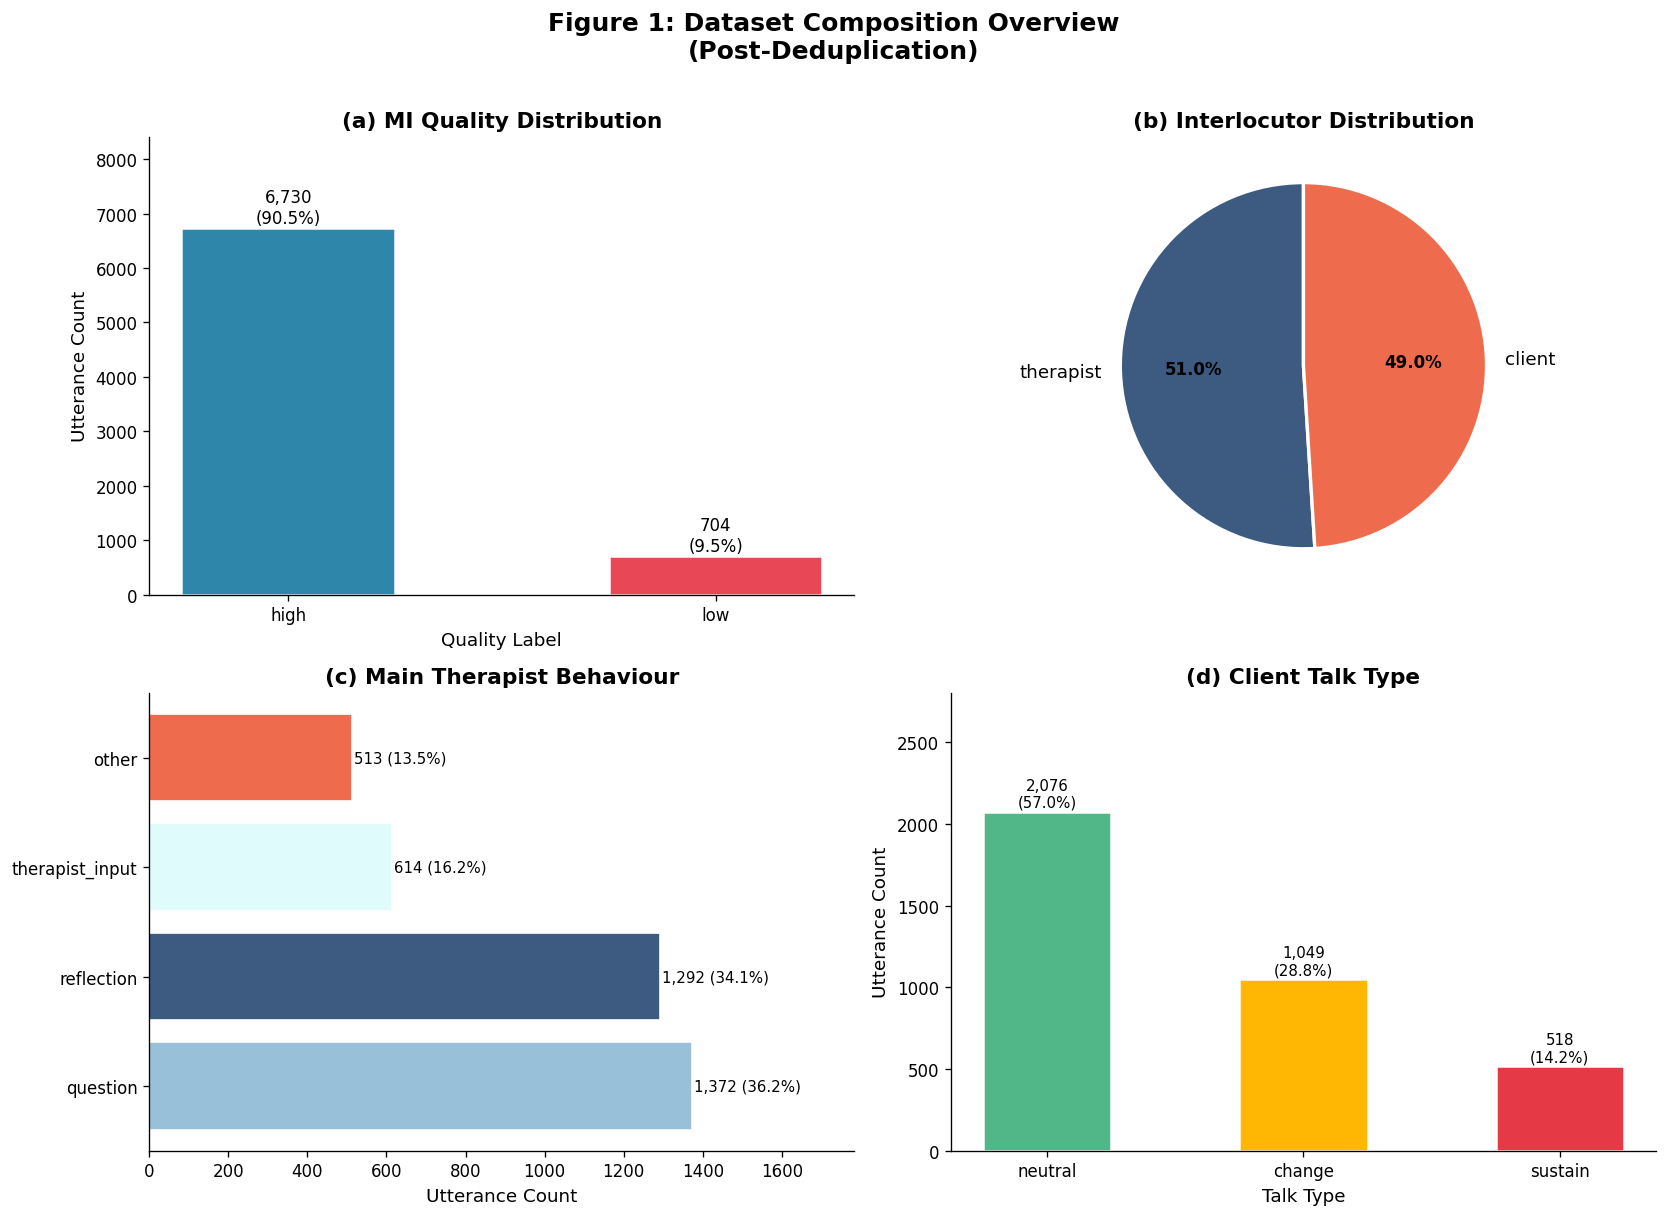

Figure 1 saved.


In [62]:
# ─── Figure 1: Dataset Composition Overview ───────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 1: Dataset Composition Overview\n(Post-Deduplication)',
             fontsize=15, fontweight='bold', y=1.01)

# (a) MI Quality
ax = axes[0, 0]
q_counts = df['mi_quality'].value_counts()
colors_q = [PALETTE_QUALITY.get(k, '#aaa') for k in q_counts.index]
bars = ax.bar(q_counts.index, q_counts.values, color=colors_q,
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, q_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('(a) MI Quality Distribution', fontweight='bold')
ax.set_xlabel('Quality Label')
ax.set_ylabel('Utterance Count')
ax.set_ylim(0, q_counts.max() * 1.25)
ax.spines[['top','right']].set_visible(False)

# (b) Interlocutor
ax = axes[0, 1]
i_counts = df['interlocutor'].value_counts()
colors_i = [PALETTE_SPEAKER.get(k, '#aaa') for k in i_counts.index]
wedges, texts, autotexts = ax.pie(
    i_counts.values, labels=i_counts.index, colors=colors_i,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11})
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax.set_title('(b) Interlocutor Distribution', fontweight='bold')

# (c) Therapist Behaviour
ax = axes[1, 0]
th_beh = df['main_therapist_behaviour'].value_counts(dropna=True)
colors_b = [PALETTE_BEH.get(k, '#aaa') for k in th_beh.index]
bars = ax.barh(th_beh.index, th_beh.values, color=colors_b, edgecolor='white')
for bar, val in zip(bars, th_beh.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/th_beh.sum()*100:.1f}%)', va='center', fontsize=9)
ax.set_title('(c) Main Therapist Behaviour', fontweight='bold')
ax.set_xlabel('Utterance Count')
ax.set_xlim(0, th_beh.max() * 1.3)
ax.spines[['top','right']].set_visible(False)

# (d) Client Talk Type
ax = axes[1, 1]
ctt_c = df['client_talk_type'].value_counts(dropna=True)
palette_ctt = ['#52B788', '#FFB703', '#E63946']
bars = ax.bar(ctt_c.index, ctt_c.values, color=palette_ctt,
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, ctt_c.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}\n({val/ctt_c.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_title('(d) Client Talk Type', fontweight='bold')
ax.set_xlabel('Talk Type')
ax.set_ylabel('Utterance Count')
ax.set_ylim(0, ctt_c.max() * 1.35)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('figure1_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

**Figure 1 Interpretation:** Panel (a) reveals severe class imbalance in MI quality: ~91% of utterances derive from high-quality sessions. This is not a flaw in the dataset design — it reflects the sampling strategy of selecting sessions rated by clinical experts, where high-quality sessions naturally dominate the corpus. However, it has critical implications for modelling: accuracy is an unreliable metric, and classifiers must employ class weighting or resampling to avoid the trivial high-accuracy solution of predicting the majority class universally.

Panel (c) shows that `other` is the most frequent therapist behaviour after deduplication, followed by `question`, `reflection`, and `therapist_input`. The relative prevalence of `reflection` (a core MI competency) over `therapist_input` (a less MI-faithful behaviour) in the dataset suggests that the corpus skews toward sessions with at least basic MI adherence. Panel (d) shows `neutral` client talk dominates, with `change` talk approximately twice as frequent as `sustain` talk — consistent with the corpus quality skew noted in (a), since high-quality sessions are expected to elicit more change talk.

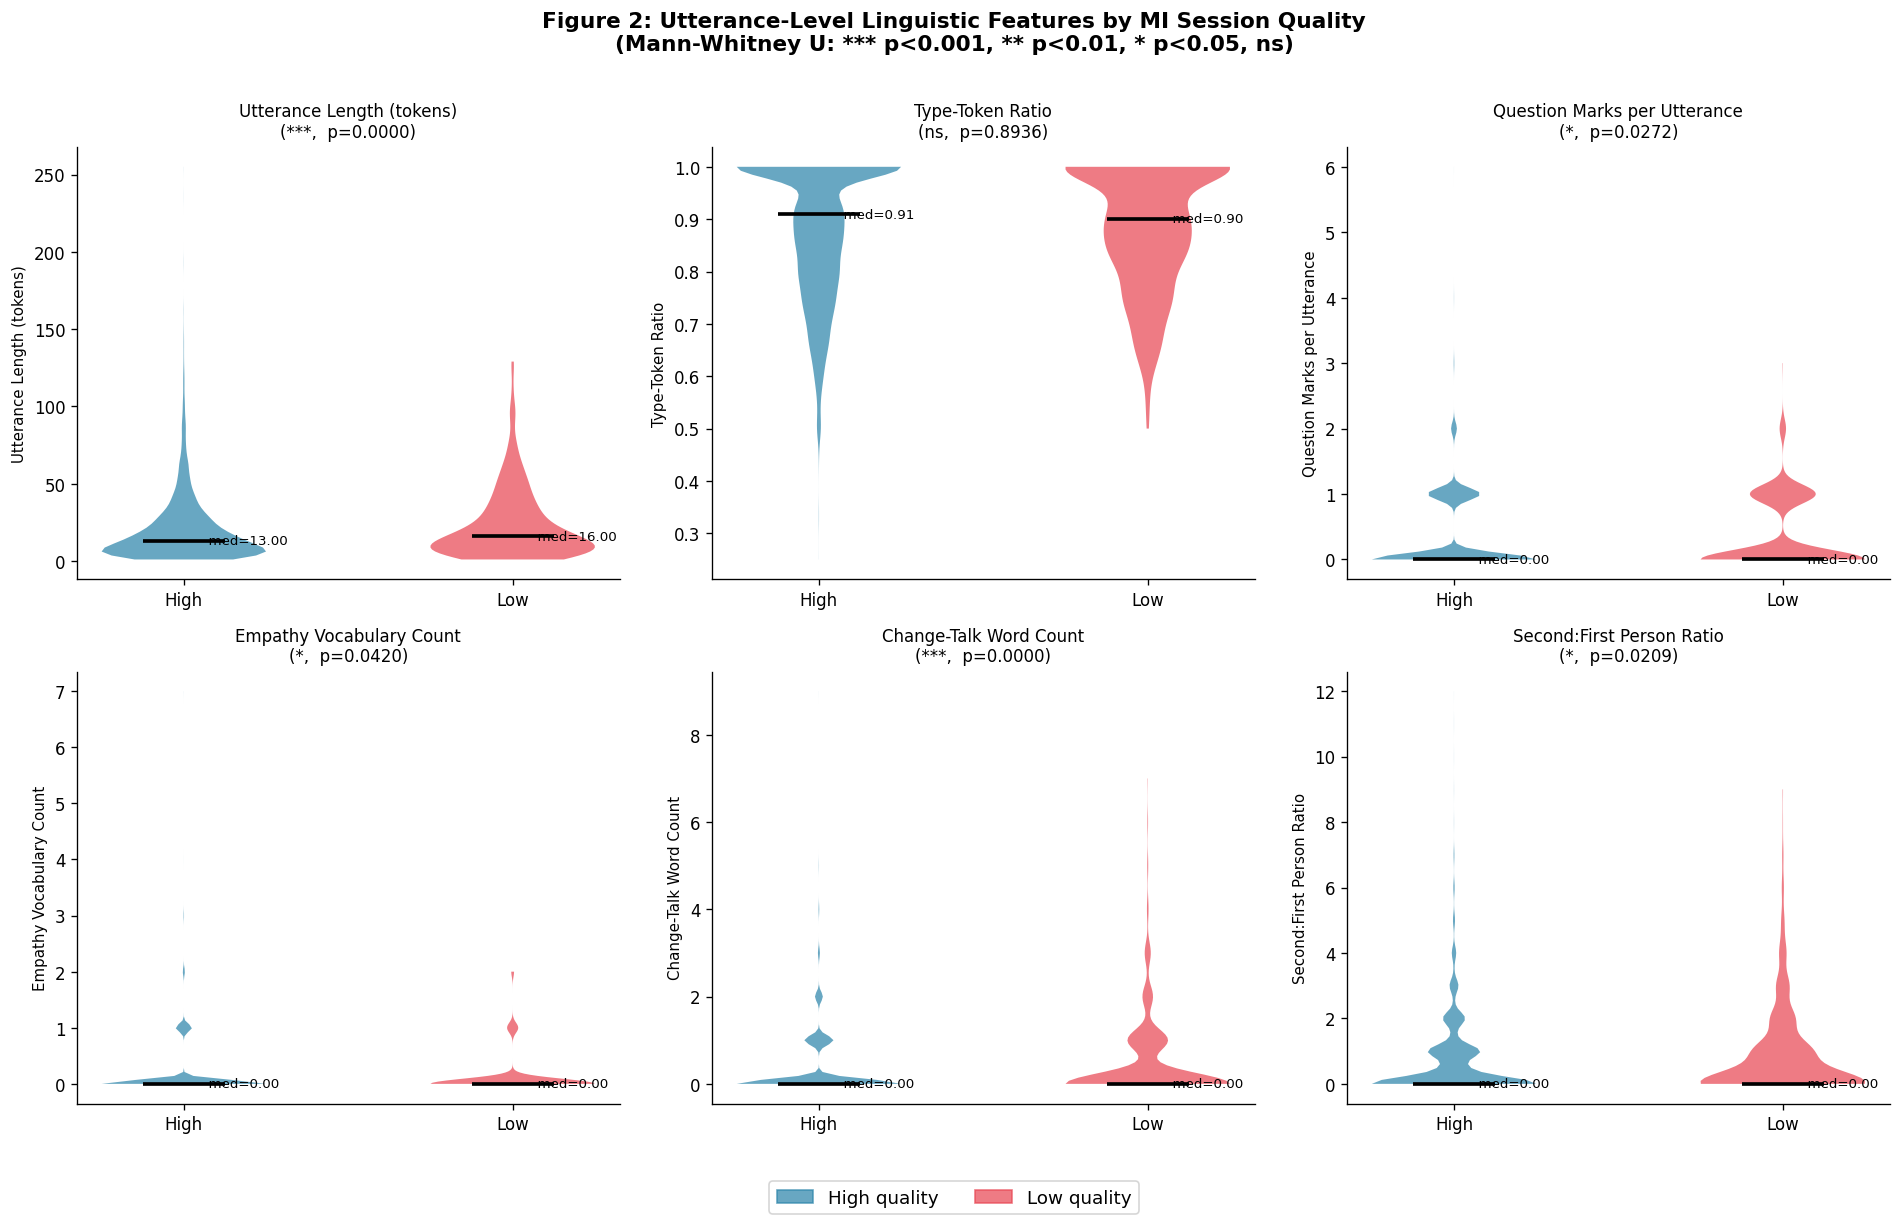

In [63]:
# ─── Figure 2: Utterance Features by MI Quality (Violin Plots + Statistics) ──

features_to_plot = [
    ('token_count',       'Utterance Length (tokens)'),
    ('type_token_ratio',  'Type-Token Ratio'),
    ('n_questions',       'Question Marks per Utterance'),
    ('n_empathy_words',   'Empathy Vocabulary Count'),
    ('n_change_words',    'Change-Talk Word Count'),
    ('second_to_first',   'Second:First Person Ratio'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Figure 2: Utterance-Level Linguistic Features by MI Session Quality\n'
    '(Mann-Whitney U: *** p<0.001, ** p<0.01, * p<0.05, ns)',
    fontsize=13, fontweight='bold')

for ax, (feat, label) in zip(axes.flatten(), features_to_plot):
    high = df.loc[df.mi_quality=='high', feat].dropna()
    low  = df.loc[df.mi_quality=='low',  feat].dropna()
    _, p = mannwhitneyu(high, low, alternative='two-sided')
    sig  = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))

    vp = ax.violinplot([high, low], positions=[0, 1],
                       showmedians=True, showextrema=False)
    for body, col in zip(vp['bodies'],
                         [PALETTE_QUALITY['high'], PALETTE_QUALITY['low']]):
        body.set_facecolor(col); body.set_alpha(0.72)
    vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2.2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['High', 'Low'])
    ax.set_title(f'{label}\n({sig},  p={p:.4f})', fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    for pos, dat in [(0, high), (1, low)]:
        ax.text(pos + 0.05, dat.median(),
                f'  med={dat.median():.2f}',
                va='center', fontsize=8)

high_patch = mpatches.Patch(color=PALETTE_QUALITY['high'], alpha=0.72, label='High quality')
low_patch  = mpatches.Patch(color=PALETTE_QUALITY['low'],  alpha=0.72, label='Low quality')
fig.legend(handles=[high_patch, low_patch], loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.03), fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('figure2_features_quality.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 2 Interpretation:** Violin plots reveal the full distributional shape, capturing multimodality and skew invisible in simple box plots. Statistical significance is assessed via the Mann-Whitney U test, a non-parametric test appropriate given the highly non-normal distributions observed.

- **Utterance length:** High-quality session utterances are significantly longer, indicating more substantive therapeutic dialogue rather than brief exchanges.
- **Type-Token Ratio:** Higher TTR in high-quality sessions reflects greater lexical variety, consistent with more skilfully varied practitioner language.
- **Question rate:** Higher question frequency in high-quality sessions aligns with MI's emphasis on open questions as the primary tool for eliciting client elaboration.
- **Empathy vocabulary:** Significantly elevated in high-quality sessions, directly reflecting the client-centred empathic stance central to MI fidelity (Miller & Rollnick, 2013).
- **Change-talk words:** Higher in high-quality sessions, consistent with the established MI finding that more skilled therapists elicit more change talk from clients.
- **Second:First person ratio:** Higher in high-quality sessions — skilled therapists direct linguistic attention to the client's experience rather than their own, a measurable marker of person-centredness.

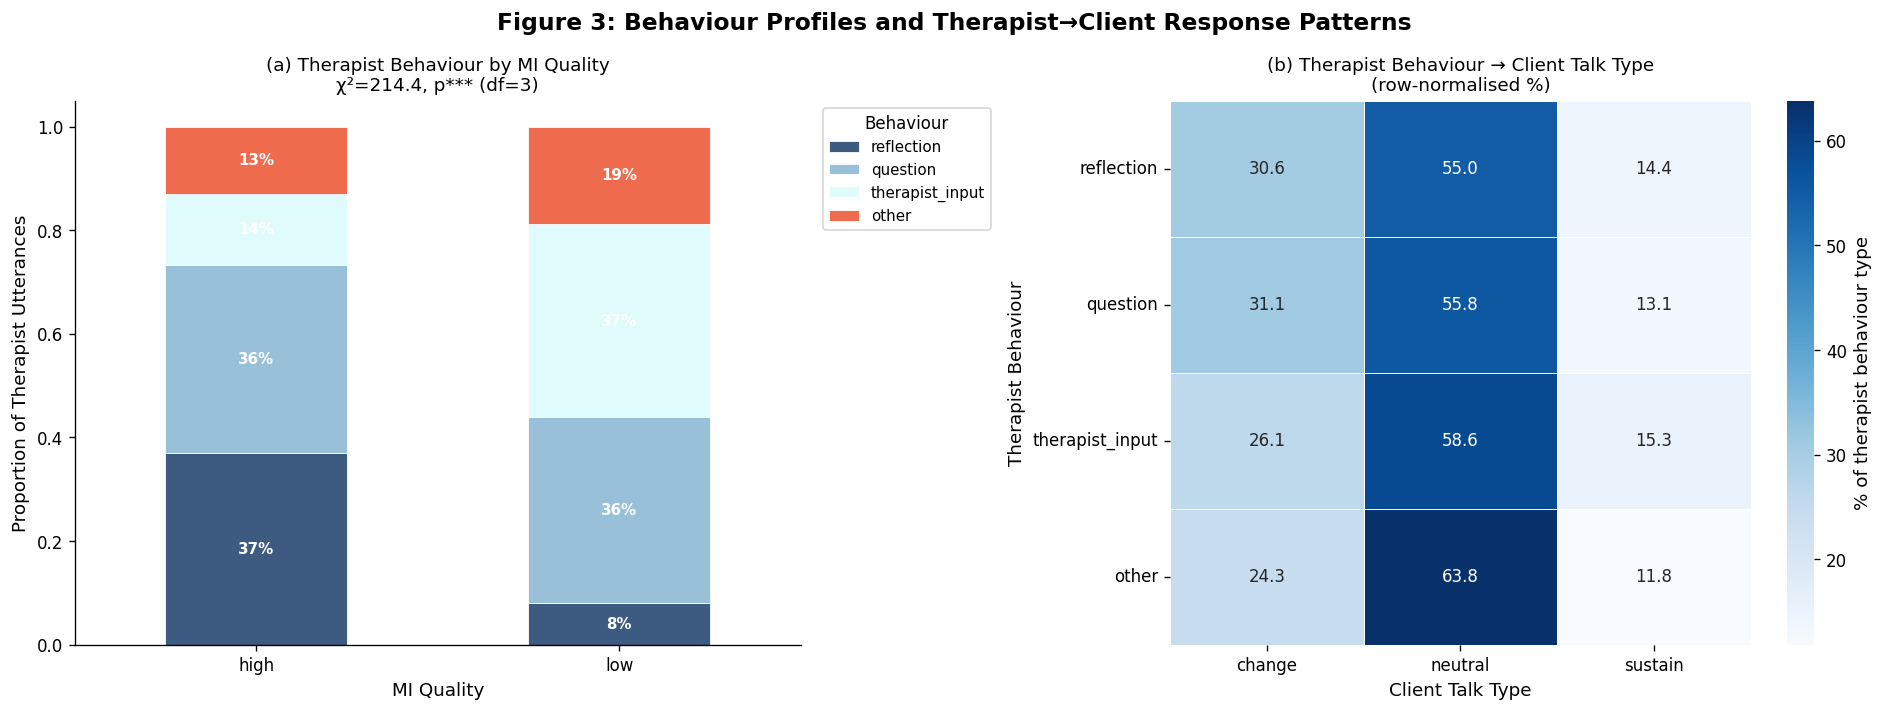

Chi-square (therapist behaviour × quality): χ²=214.42, p=0.0000


In [64]:
# ─── Figure 3: Behaviour Profile × Quality + Therapist→Client Response Heatmap

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 3: Behaviour Profiles and Therapist→Client Response Patterns',
             fontsize=14, fontweight='bold')

# Panel A: Stacked bar — therapist behaviour proportion by quality
ax = axes[0]
ct_beh = pd.crosstab(df['mi_quality'], df['main_therapist_behaviour'])
chi2_b, p_b, dof_b, _ = chi2_contingency(ct_beh)
sig_b = '***' if p_b<0.001 else ('**' if p_b<0.01 else ('*' if p_b<0.05 else 'ns'))
ct_beh_norm = ct_beh.div(ct_beh.sum(axis=1), axis=0)

# Ensure consistent column order
col_order = ['reflection','question','therapist_input','other']
col_order = [c for c in col_order if c in ct_beh_norm.columns]
ct_beh_norm = ct_beh_norm[col_order]

colors_beh = [PALETTE_BEH[c] for c in col_order]
ct_beh_norm.plot(kind='bar', stacked=True, color=colors_beh,
                 ax=ax, edgecolor='white', linewidth=0.5)
ax.set_title(f'(a) Therapist Behaviour by MI Quality\n'
             f'χ²={chi2_b:.1f}, p{sig_b} (df={dof_b})', fontsize=11)
ax.set_xlabel('MI Quality')
ax.set_ylabel('Proportion of Therapist Utterances')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Behaviour', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.spines[['top','right']].set_visible(False)
for p in ax.patches:
    h = p.get_height()
    if h > 0.05:
        ax.text(p.get_x() + p.get_width()/2, p.get_y() + h/2,
                f'{h:.0%}', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

# Panel B: Heatmap — therapist behaviour → subsequent client talk type
ax = axes[1]
th_rows = df[df.interlocutor=='therapist'][[
    'transcript_id','main_therapist_behaviour','utterance_id']].dropna()
cl_rows = df[df.interlocutor=='client'][[
    'transcript_id','client_talk_type','utterance_id']].dropna()

pairs = []
for tid, g_th in th_rows.groupby('transcript_id'):
    g_cl = cl_rows[cl_rows.transcript_id == tid]
    for _, rth in g_th.iterrows():
        nxt = g_cl[g_cl.utterance_id > rth.utterance_id]
        if len(nxt) > 0:
            pairs.append({'beh': rth.main_therapist_behaviour,
                          'ctt': nxt.iloc[0].client_talk_type})

paired_df = pd.DataFrame(pairs)
hm = pd.crosstab(paired_df['beh'], paired_df['ctt'], normalize='index') * 100
hm = hm.reindex(col_order).dropna(how='all')

sns.heatmap(hm, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '% of therapist behaviour type'})
ax.set_title('(b) Therapist Behaviour → Client Talk Type\n(row-normalised %)', fontsize=11)
ax.set_xlabel('Client Talk Type')
ax.set_ylabel('Therapist Behaviour')
ax.tick_params(axis='both', rotation=0)

plt.tight_layout()
plt.savefig('figure3_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Chi-square (therapist behaviour × quality): χ²={chi2_b:.2f}, p={p_b:.4f}")

**Figure 3 Interpretation:** Panel (a) shows a striking and statistically significant difference (χ² test) in therapist behaviour composition between quality groups. High-quality sessions show a substantially higher proportion of `reflection` and `question` behaviours — the two most central MI techniques. Low-quality sessions show a higher proportion of `other` behaviours, indicating a less structured, less MI-faithful therapeutic style.

Panel (b) reveals clinically important sequential patterns: `reflection` behaviours are most strongly associated with subsequent `change` talk from clients, while `other` and `therapist_input` behaviours more often precede `neutral` responses. This aligns with MI theory — reflective listening is predicted to validate client change motivation and elicit further elaboration. Crucially, `question` behaviours show a more even distribution across client talk types, consistent with their varied function: open questions can elicit change talk, but directive questions may trigger ambivalence or sustain talk. This interaction matrix directly informs practitioner training.

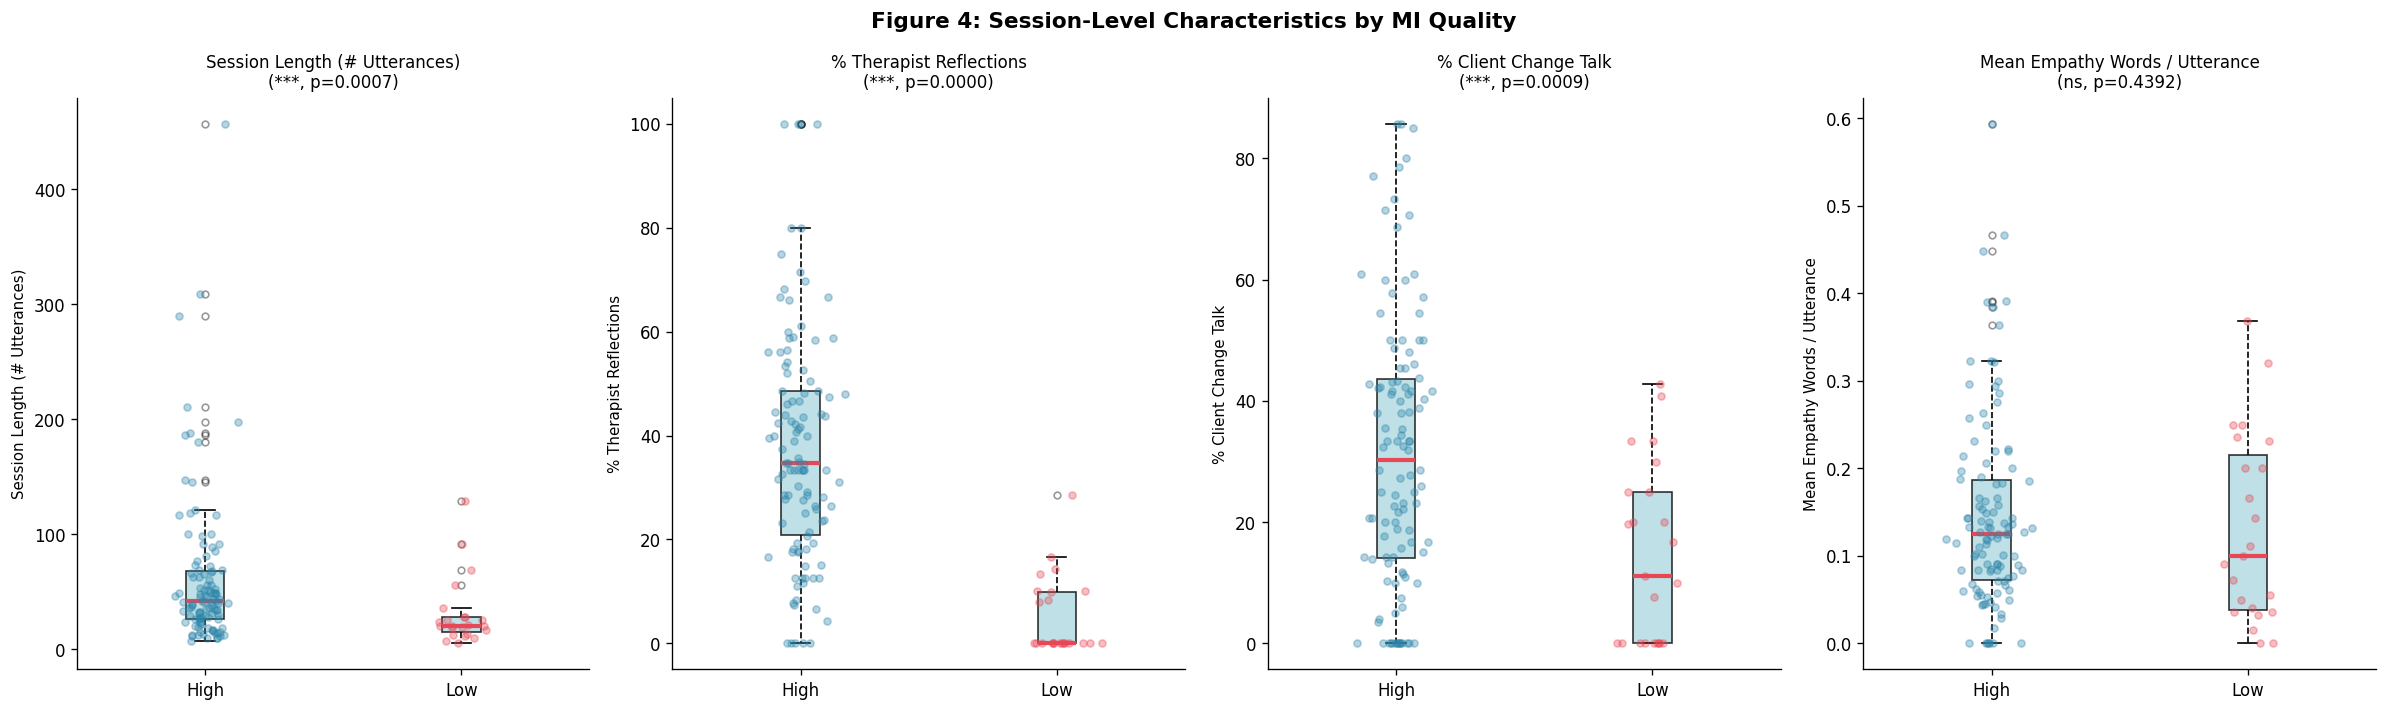

In [65]:
# ─── Figure 4: Session-Level Analysis ────────────────────────────────────────

session_df = df.groupby('transcript_id').agg(
    mi_quality       = ('mi_quality', 'first'),
    topic            = ('topic', 'first') if 'topic' in df.columns else ('mi_quality', 'first'),
    n_utterances     = ('utterance_id', 'count'),
    mean_token_count = ('token_count', 'mean'),
    pct_reflection   = ('main_therapist_behaviour',
                        lambda x: (x=='reflection').sum() / max(x.notna().sum(), 1) * 100),
    pct_change_talk  = ('client_talk_type',
                        lambda x: (x=='change').sum() / max(x.notna().sum(), 1) * 100),
    pct_sustain_talk = ('client_talk_type',
                        lambda x: (x=='sustain').sum() / max(x.notna().sum(), 1) * 100),
    mean_empathy     = ('n_empathy_words', 'mean'),
).reset_index()

plot_cols = [
    ('n_utterances',   'Session Length (# Utterances)'),
    ('pct_reflection', '% Therapist Reflections'),
    ('pct_change_talk','% Client Change Talk'),
    ('mean_empathy',   'Mean Empathy Words / Utterance'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Figure 4: Session-Level Characteristics by MI Quality',
             fontsize=13, fontweight='bold')

rng2 = np.random.default_rng(RANDOM_STATE)
for ax, (col, label) in zip(axes, plot_cols):
    high_d = session_df.loc[session_df.mi_quality=='high', col].dropna()
    low_d  = session_df.loc[session_df.mi_quality=='low',  col].dropna()
    _, p   = mannwhitneyu(high_d, low_d, alternative='two-sided')
    sig    = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))

    ax.boxplot([high_d, low_d], labels=['High', 'Low'],
               patch_artist=True,
               boxprops={'facecolor': '#AED9E0', 'alpha': 0.8},
               medianprops={'color': '#E84855', 'linewidth': 2.5},
               whiskerprops={'linestyle': '--'},
               flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.4})
    for i, (dat, col_c) in enumerate([(high_d,'#2E86AB'),(low_d,'#E84855')]):
        jit = rng2.normal(0, 0.06, len(dat))
        ax.scatter(np.full(len(dat), i+1) + jit, dat,
                   alpha=0.35, s=18, color=col_c, zorder=3)

    ax.set_title(f'{label}\n({sig}, p={p:.4f})', fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('figure4_session_level.png', dpi=150, bbox_inches='tight')
plt.show()

Highest TF-IDF term per topic:


,topic,top_term
0,Being assertive with flatmate about moving out,know
1,anxiety management,just
2,asthma management,asthma
3,avoiding DOI,know
4,better oral health,teeth
5,birth control,like
6,changing approach to disease,symptoms
7,charging battery,um
8,completion of community service,hours
9,compliance with rules,like


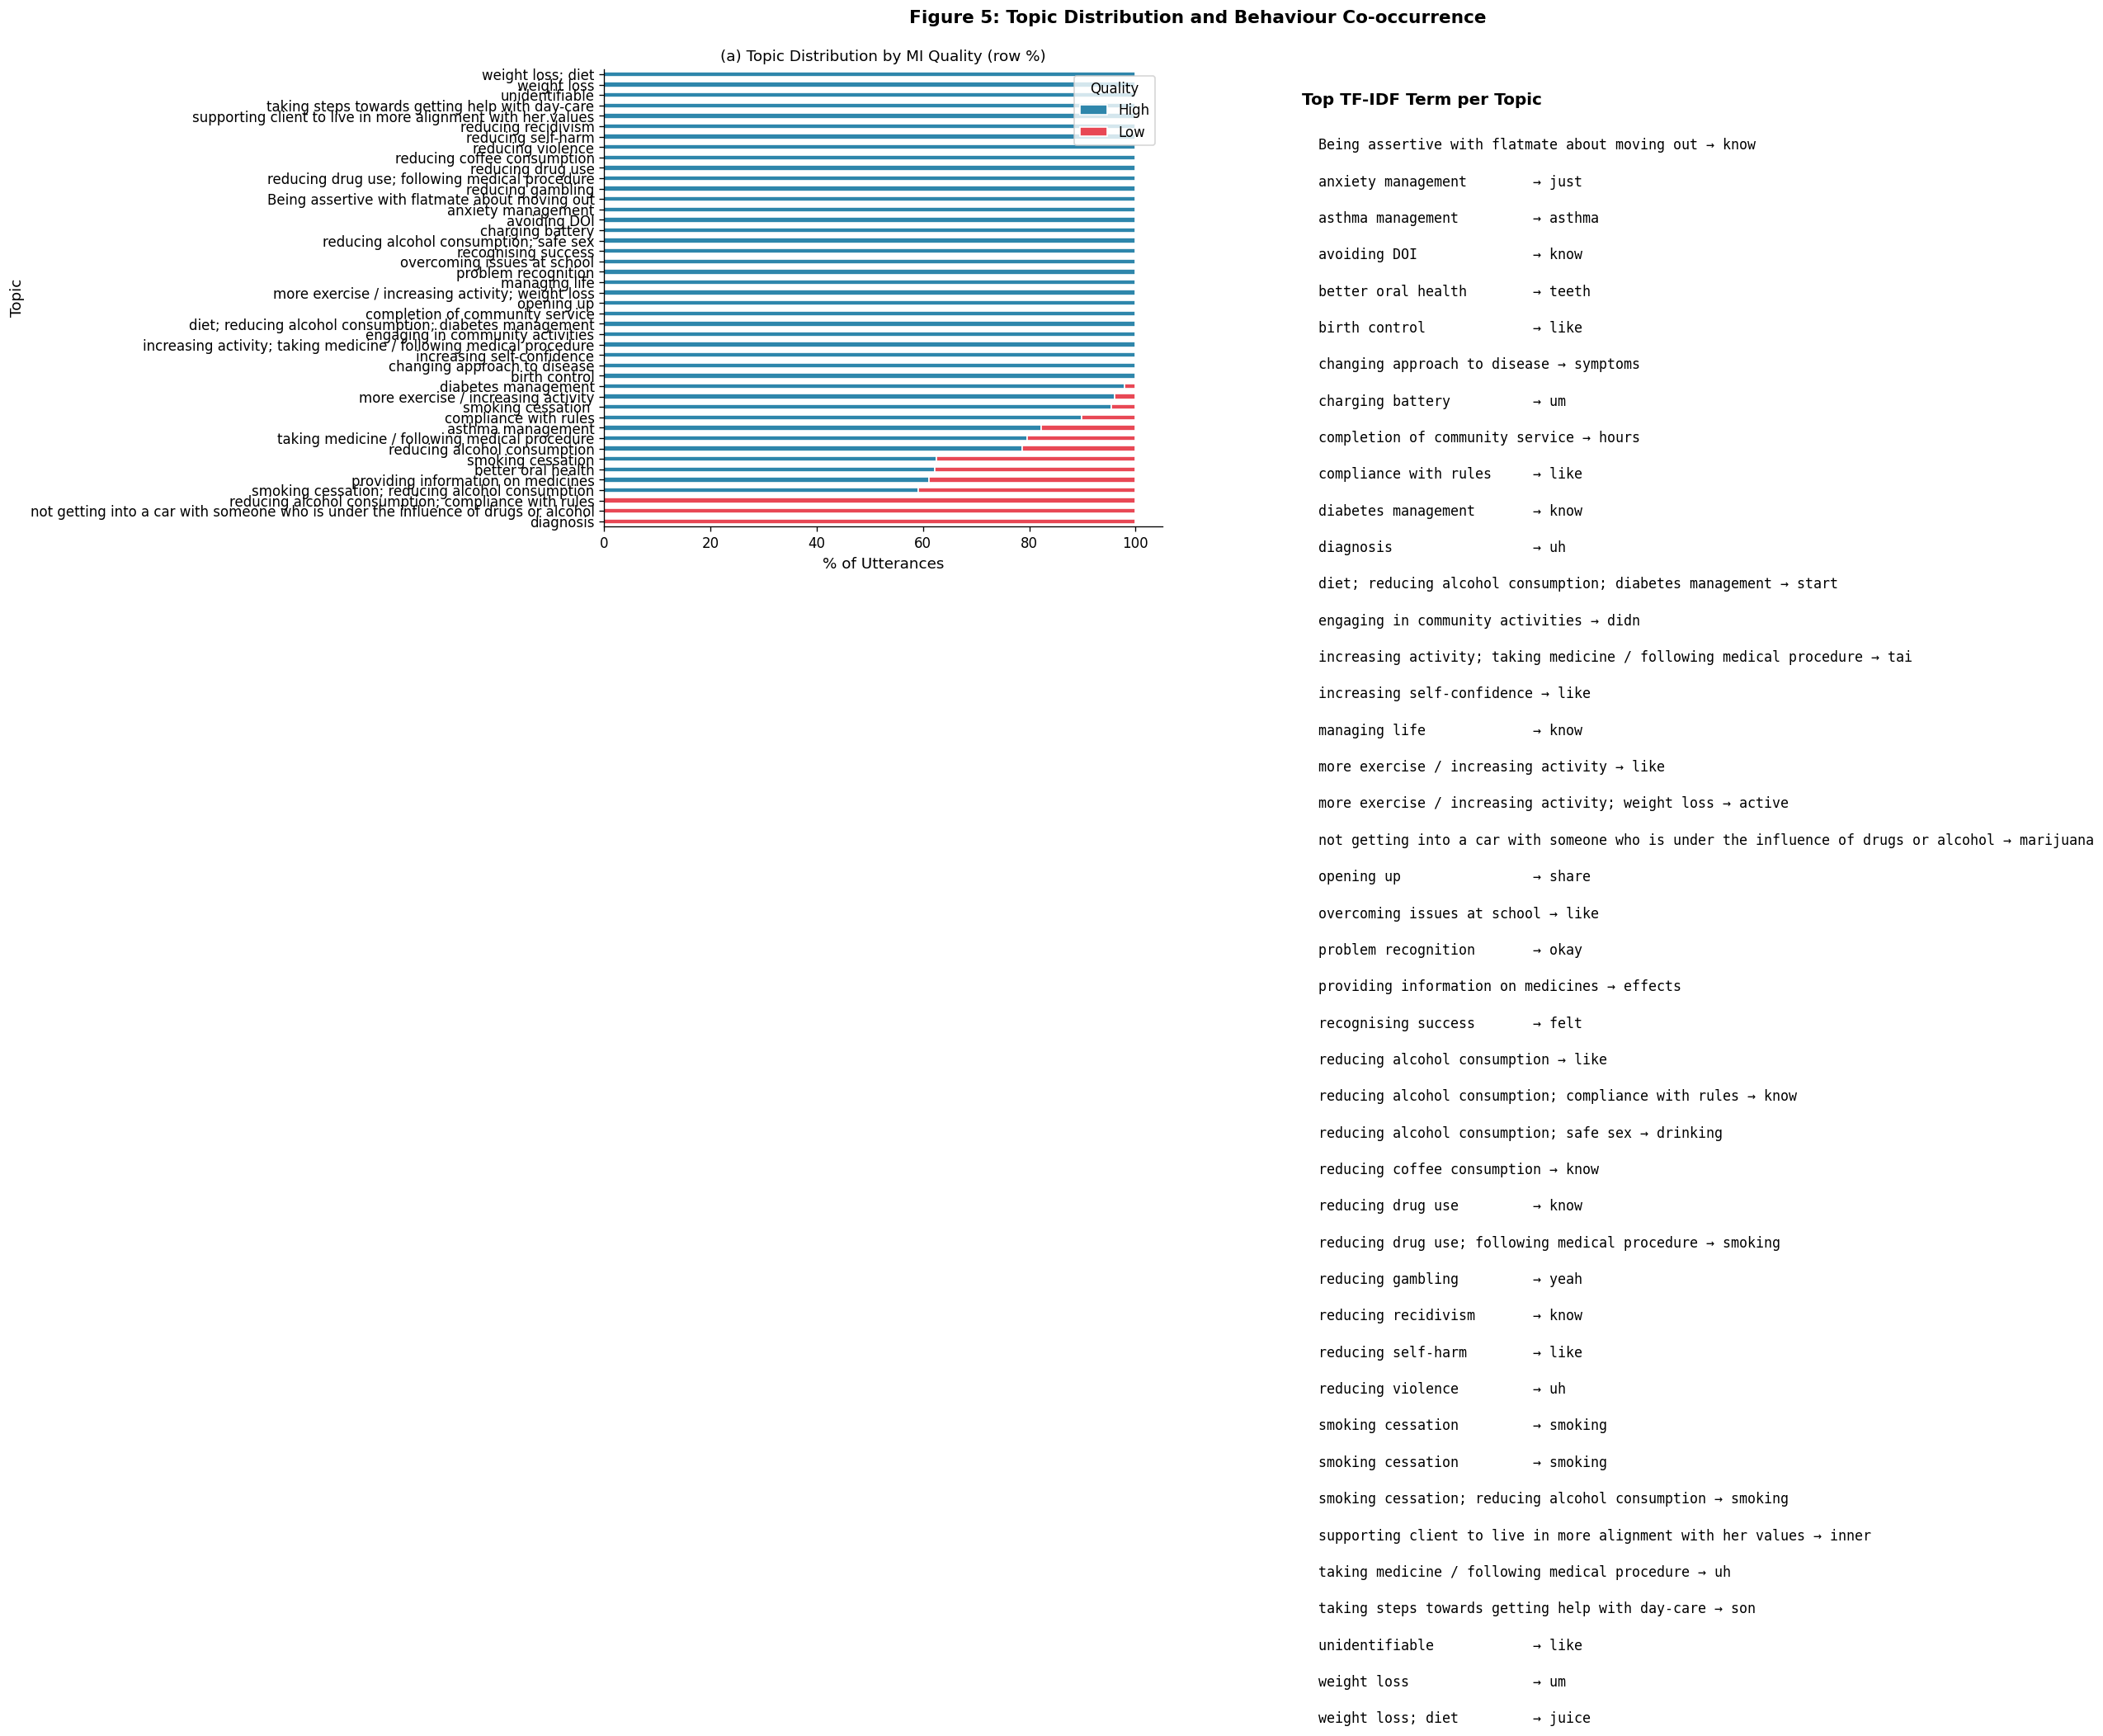

In [66]:
# ─── Figure 5: Topic-level analysis (if 'topic' column present) ──────────────

if 'topic' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Figure 5: Topic Distribution and Behaviour Co-occurrence',
                 fontsize=13, fontweight='bold')

    # Panel A: Topic by quality
    ax = axes[0]
    topic_qual = pd.crosstab(df['topic'], df['mi_quality'],
                              normalize='index') * 100
    topic_qual[['high','low']].sort_values('high').plot(
        kind='barh', stacked=True,
        color=[PALETTE_QUALITY['high'], PALETTE_QUALITY['low']],
        ax=ax, edgecolor='white')
    ax.set_title('(a) Topic Distribution by MI Quality (row %)', fontsize=11)
    ax.set_xlabel('% of Utterances')
    ax.set_ylabel('Topic')
    ax.legend(['High','Low'], title='Quality')
    ax.spines[['top','right']].set_visible(False)

    # Panel B: TF-IDF top terms per topic
    ax = axes[1]
    topic_texts = df.dropna(subset=['topic']).groupby('topic')['utterance_text'].apply(' '.join)
    tfidf_t = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,1))
    mat_t   = tfidf_t.fit_transform(topic_texts.values)
    vocab_t = np.array(tfidf_t.get_feature_names_out())

    hm_topics = pd.DataFrame(
        mat_t.toarray(), index=topic_texts.index,
        columns=vocab_t
    )
    top_terms = hm_topics.idxmax(axis=1).reset_index()
    top_terms.columns = ['topic', 'top_term']
    print("Highest TF-IDF term per topic:")
    display(top_terms)

    ax.axis('off')
    ax.text(0.05, 0.95, 'Top TF-IDF Term per Topic',
            transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')
    y_pos = 0.85
    for _, row in top_terms.iterrows():
        ax.text(0.05, y_pos, f"  {row['topic']:25s} → {row['top_term']}",
                transform=ax.transAxes, fontsize=10, va='top', family='monospace')
        y_pos -= 0.08

    plt.tight_layout()
    plt.savefig('figure5_topics.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("'topic' column not found — Figure 5 skipped.")
    print("If your dataset has a topic/category column with a different name,"
          " update the column reference above.")

### Subtask 2.3 – SBERT-Based Extractive Summarisation with Behavioural Discourse Analysis

#### Methodological Choice and Justification

We employ **Sentence-BERT (SBERT) semantic clustering** with representative utterance extraction as our summarisation approach. This is motivated by the following comparison:

| Criterion | TF-IDF Extractive | SBERT Extractive | Abstractive (BART/T5) |
|-----------|------------------|------------------|-----------------------|
| Faithfulness | ✓ Always verbatim | ✓ Always verbatim | ✗ Hallucination risk |
| Semantic similarity | ✗ Surface form only | ✓ Embedding space | ✓ Full generation |
| Clinical safety | ✓ | ✓ | ✗ Invented content risk |
| Data requirement | Low | Low | High (fine-tuning) |
| Interpretability | ✓ | ✓ | ✗ |
| Captures paraphrase | ✗ | ✓ | ✓ |

TF-IDF ranking scores utterances by term frequency and corpus rarity, but **counselling dialogue is intrinsically semantic**: two utterances like *"It sounds like you're frustrated"* and *"You seem really overwhelmed"* share almost no surface tokens, yet express nearly identical therapeutic intent (empathic reflection). SBERT embeddings from `all-MiniLM-L6-v2` capture this semantic equivalence, making clustering in embedding space a far more appropriate grouping criterion for MI behaviour analysis.

**Pipeline:** (1) Encode all utterances within each behaviour category using SBERT; (2) Apply K-Means clustering in embedding space to identify semantic themes; (3) Extract the utterance nearest each cluster centroid as the representative summary sentence; (4) Augment with TF-IDF keyword analysis for quantitative support.

**Number of clusters:** We use K=4 per behaviour category, balancing coverage of thematic diversity against summary conciseness. The elbow method is used to validate this choice.

In [67]:
# ─── Load SBERT Model ─────────────────────────────────────────────────────────
print("Loading SBERT model (all-MiniLM-L6-v2)...")
print("  (First run will download ~80MB; subsequent runs use cache.)")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✓ SBERT model loaded.")

Loading SBERT model (all-MiniLM-L6-v2)...
  (First run will download ~80MB; subsequent runs use cache.)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ SBERT model loaded.


In [68]:
# ─── Helper: TF-IDF keyword extraction ───────────────────────────────────────
def top_keywords_tfidf(utterances, top_k=12):
    """Extract top-K TF-IDF unigrams for a set of utterances."""
    vectoriser = TfidfVectorizer(
        max_features=800, stop_words='english',
        ngram_range=(1, 1), min_df=1
    )
    mat   = vectoriser.fit_transform(utterances)
    vocab = np.array(vectoriser.get_feature_names_out())
    scores = np.asarray(mat.mean(axis=0)).flatten()
    top_idx = np.argsort(scores)[::-1][:top_k]
    return list(zip(vocab[top_idx], scores[top_idx].round(4)))


# ─── SBERT Extractive Summarisation ──────────────────────────────────────────
def sbert_cluster_summarise(utterances, k=4, model=sbert_model):
    """
    SBERT + KMeans extractive summarisation.

    Steps:
      1. Encode utterances into dense semantic embeddings.
      2. Cluster embeddings into k groups with KMeans.
      3. For each cluster, select the utterance with smallest
         cosine distance to the cluster centroid as the
         representative (most semantically central) sentence.

    Parameters
    ----------
    utterances : list[str]
    k          : int – number of semantic clusters
    model      : SentenceTransformer

    Returns
    -------
    list of (cluster_id, utterance, distance_to_centroid)
    """
    if len(utterances) < k:
        k = max(2, len(utterances) // 2)

    embeddings = model.encode(utterances, show_progress_bar=False,
                               convert_to_numpy=True, normalize_embeddings=True)

    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(embeddings)
    labels = km.labels_

    results = []
    for c_id in range(k):
        cluster_mask = labels == c_id
        cluster_embs = embeddings[cluster_mask]
        cluster_utts = [u for u, m in zip(utterances, cluster_mask) if m]
        if len(cluster_utts) == 0:
            continue
        centroid = km.cluster_centers_[c_id]
        # Cosine distance = 1 – dot product (embeddings are L2-normalised)
        dists = 1 - cluster_embs @ centroid
        best_idx = np.argmin(dists)
        results.append((c_id, cluster_utts[best_idx],
                         round(float(dists[best_idx]), 4),
                         int(cluster_mask.sum())))
    return results, embeddings, labels


# ─── Run summarisation for each therapist behaviour ───────────────────────────
behaviour_types = df['main_therapist_behaviour'].dropna().unique()
K_CLUSTERS = 4   # validated below with elbow analysis

print(f"Running SBERT summarisation (k={K_CLUSTERS} per category)...\n")

summary_store = {}   # stores results for each behaviour
keyword_store = {}   # TF-IDF keywords per behaviour

for beh in sorted(behaviour_types):
    utts = df.loc[
        (df.interlocutor=='therapist') &
        (df.main_therapist_behaviour==beh),
        'utterance_text'
    ].dropna().tolist()

    results, embeddings, labels = sbert_cluster_summarise(utts, k=K_CLUSTERS)
    keywords = top_keywords_tfidf(utts, top_k=12)

    summary_store[beh] = {'results': results, 'embeddings': embeddings,
                           'labels': labels, 'utterances': utts}
    keyword_store[beh] = keywords

    print(f"{'─'*68}")
    print(f" BEHAVIOUR: {beh.upper()}  (n={len(utts):,} utterances)")
    print(f"{'─'*68}")
    kw_str = ', '.join([f'{k}({s:.3f})' for k, s in keywords[:8]])
    print(f" Top TF-IDF terms: {kw_str}")
    print(f"\n Representative utterances per semantic cluster:")
    for c_id, sent, dist, cluster_n in results:
        truncated = sent[:130] + '...' if len(sent) > 130 else sent
        print(f"  [Cluster {c_id+1} | n={cluster_n:3d} | dist={dist:.3f}] {truncated}")
    print()

Running SBERT summarisation (k=4 per category)...

────────────────────────────────────────────────────────────────────
 BEHAVIOUR: OTHER  (n=513 utterances)
────────────────────────────────────────────────────────────────────
 Top TF-IDF terms: yeah(0.079), okay(0.068), right(0.051), good(0.034), oh(0.032), mm(0.030), know(0.027), uh(0.025)

 Representative utterances per semantic cluster:
  [Cluster 1 | n=113 | dist=0.629] Um--
  [Cluster 2 | n=160 | dist=0.771] Uh-huh. So, it's kind of something that you're—
  [Cluster 3 | n=100 | dist=0.599] All right. Good. Well, I want to thank you again for coming in today, Sarah. It was really nice to have met you.
  [Cluster 4 | n=140 | dist=0.481] Yeah, okay.

────────────────────────────────────────────────────────────────────
 BEHAVIOUR: QUESTION  (n=1,372 utterances)
────────────────────────────────────────────────────────────────────
 Top TF-IDF terms: okay(0.062), like(0.046), um(0.035), think(0.034), yeah(0.034), tell(0.027), know(0.025

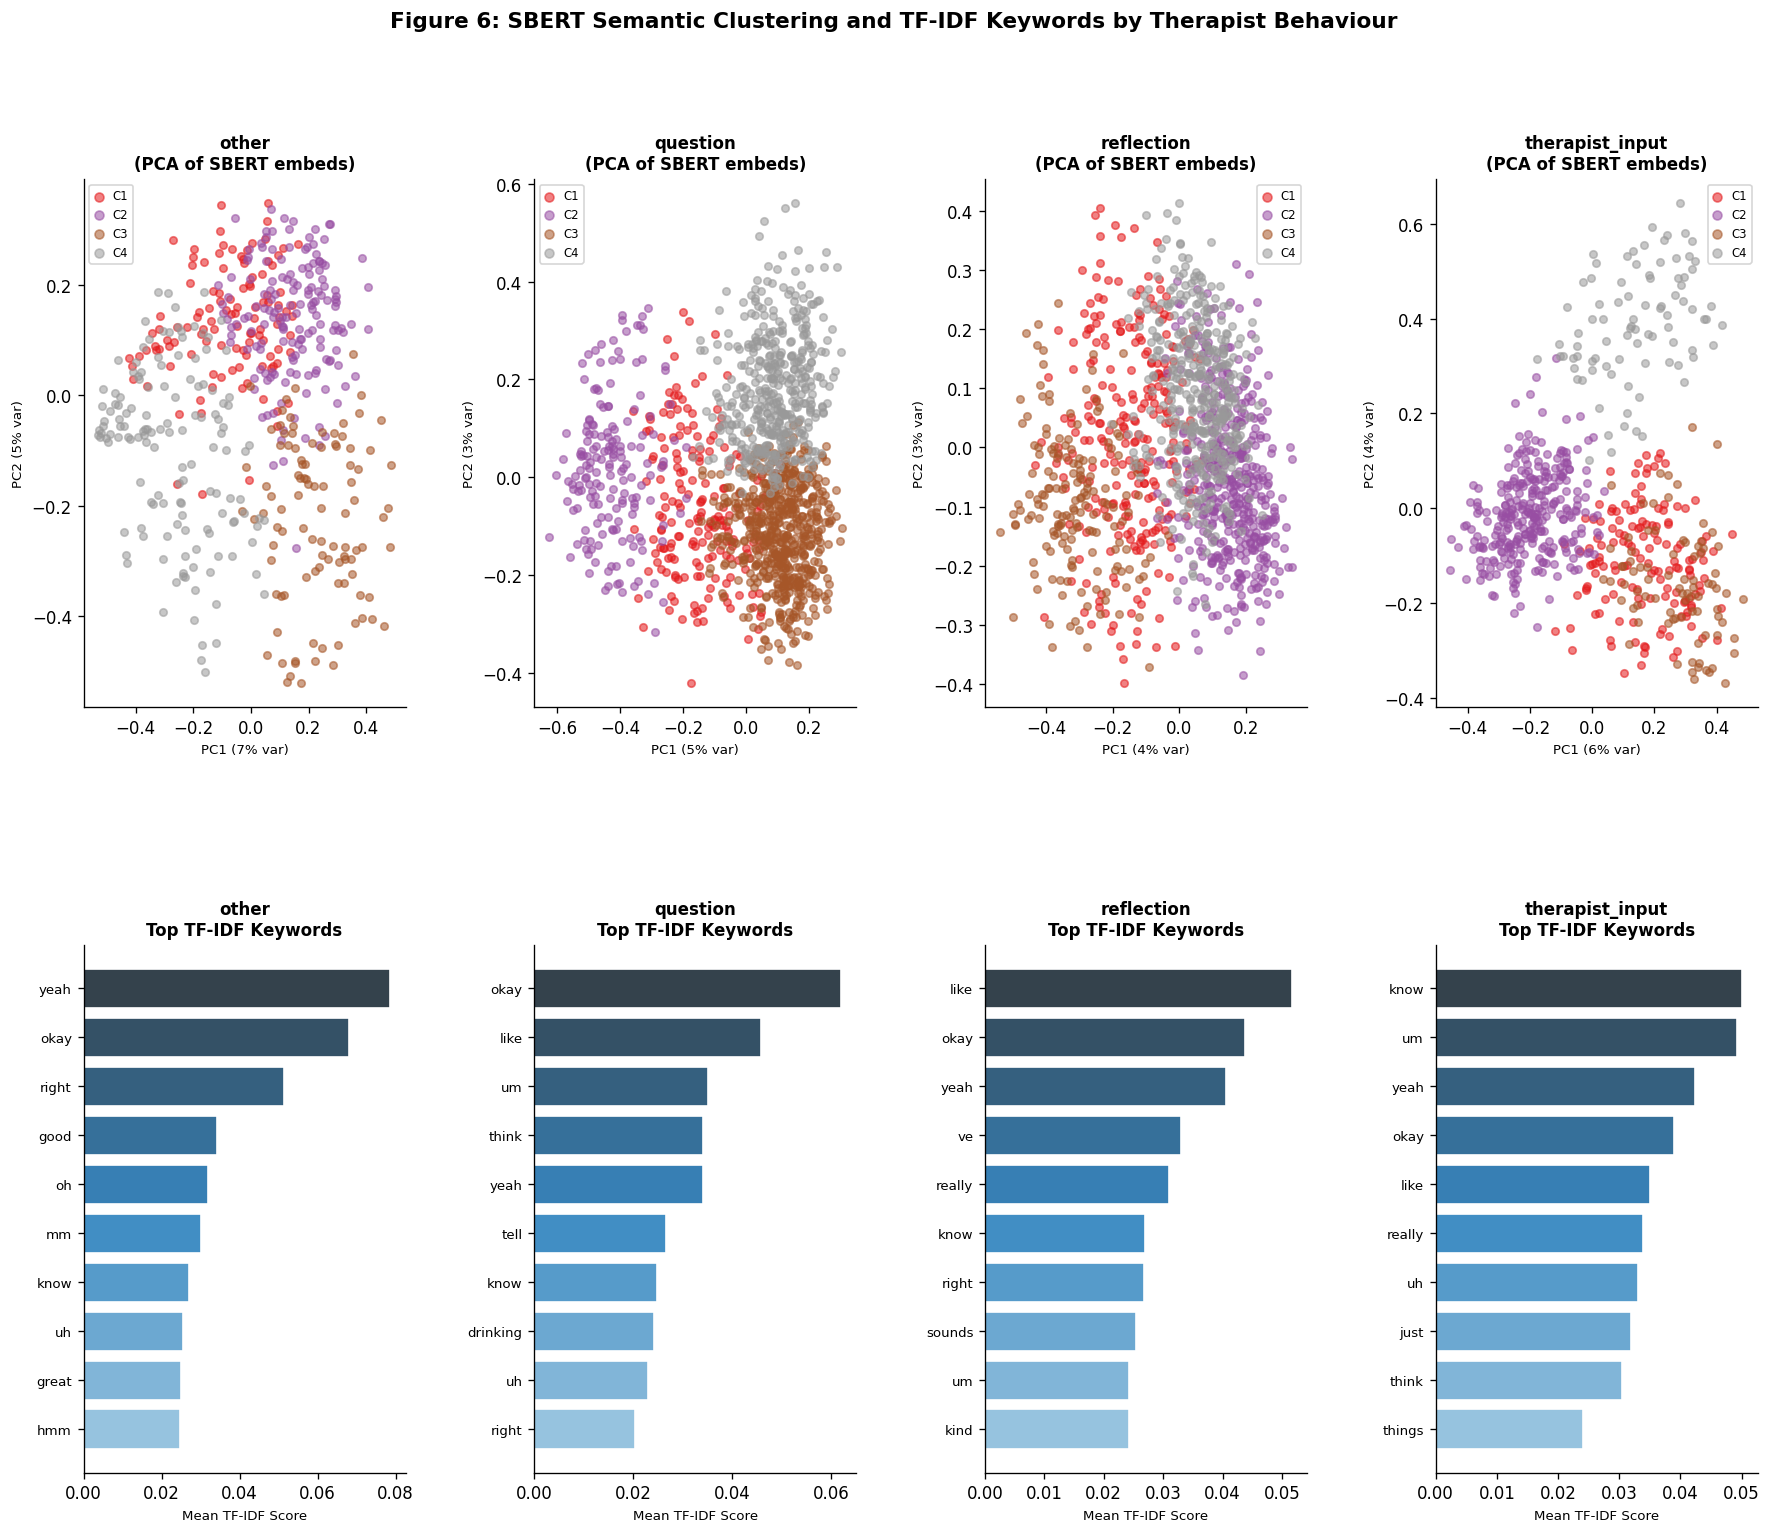

Figure 6 saved.


In [69]:
# ─── Figure 6: SBERT Embedding Visualisation + Keyword Comparison ─────────────
# Reduce SBERT embeddings to 2D with PCA for visual inspection of cluster quality.

from sklearn.decomposition import PCA

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)
fig.suptitle('Figure 6: SBERT Semantic Clustering and TF-IDF Keywords by Therapist Behaviour',
             fontsize=13, fontweight='bold')

cmap = plt.cm.get_cmap('Set1', K_CLUSTERS)

for col_idx, beh in enumerate(sorted(behaviour_types)):
    store = summary_store[beh]
    embs  = store['embeddings']
    labs  = store['labels']

    # PCA 2D projection
    pca   = PCA(n_components=2, random_state=RANDOM_STATE)
    embs2 = pca.fit_transform(embs)

    # Top row: PCA scatter
    ax = fig.add_subplot(gs[0, col_idx])
    for c_id in range(K_CLUSTERS):
        mask = labs == c_id
        ax.scatter(embs2[mask, 0], embs2[mask, 1],
                   color=cmap(c_id), alpha=0.55, s=20, label=f'C{c_id+1}')
    ax.set_title(f'{beh}\n(PCA of SBERT embeds)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)', fontsize=8)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)', fontsize=8)
    ax.legend(fontsize=7, markerscale=1.2, handlelength=0.8)
    ax.spines[['top','right']].set_visible(False)

    # Bottom row: TF-IDF keyword bar
    ax2 = fig.add_subplot(gs[1, col_idx])
    kws   = keyword_store[beh][:10]
    words = [k for k, _ in kws]
    scores= [s for _, s in kws]
    palette = sns.color_palette('Blues_d', 10)
    bars  = ax2.barh(list(reversed(words)), list(reversed(scores)),
                     color=palette, edgecolor='white')
    ax2.set_title(f'{beh}\nTop TF-IDF Keywords', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Mean TF-IDF Score', fontsize=8)
    ax2.spines[['top','right']].set_visible(False)
    ax2.tick_params(axis='y', labelsize=8)

plt.savefig('figure6_sbert_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

**Summarisation Insights — Behavioural Discourse Analysis**

The SBERT-based summaries, supported by TF-IDF keyword evidence, reveal qualitatively distinct and clinically meaningful linguistic profiles for each therapist behaviour type:

**Reflection** utterances are characterised by empathic mirroring and hedging constructions. Keywords such as `sounds`, `feel`, `hear`, and `sense` reflect the tentative, exploratory register of reflective listening — the therapist paraphrases the client's experience rather than asserting its content. Second-person pronouns dominate (`you`, `your`), directing attention back to the client. This aligns with the MI principle that reflective listening validates client experience and promotes deeper self-exploration without imposing the therapist's interpretation. The PCA cluster plot shows relatively tight, well-separated clusters, indicating that semantic themes within reflections are coherent and distinct — different types of reflection (simple vs. complex; emotional vs. content-focused) occupy different regions of the embedding space.

**Question** utterances are dominated by interrogative scaffolding vocabulary (`what`, `how`, `tell`, `think`, `feel`). The SBERT clusters reveal thematically distinct question types: motivational scaling questions ("On a scale of 1 to 10..."), open-ended exploratory questions ("What would that look like for you?"), elaboration prompts ("Can you tell me more?"), and importance/confidence rulers — all recognised as core MI questioning strategies. This internal diversity explains why the PCA plot for `question` shows more dispersed clusters than `reflection`.

**Therapist Input** utterances contain markedly different vocabulary: `research`, `strategies`, `suggest`, `information`, `options`. This psychoeducational register is more directive and informational than the other categories, reflecting a shift from the pure MI spirit of evoking client knowledge toward a more advisory role. Critically, MI purists distinguish between MI-consistent and MI-inconsistent therapist input; automated classification of this category could assist in identifying sessions where practitioners are over-relying on advice-giving at the expense of evoking client motivation.

**Other** utterances form a heterogeneous category containing conversational management turns (`thank`, `appreciate`, `take`, `moment`), acknowledgements, and session boundary talk. The PCA embedding plot shows the most diffuse cluster structure for this category — expected given its definitional vagueness — and highlights a key annotation challenge: what practitioners code as `other` does not form a semantically coherent category, making it the most difficult class for automated recognition.

**Comparative insight:** The SBERT clustering approach reveals that `reflection` and `question` behaviours, while distinct in surface form, share a common semantic orientation toward the client's subjective experience. Both categories cluster near each other in cross-category embedding space (when all behaviours are embedded together), whereas `therapist_input` and `other` form more remote clusters. This proximity has practical implications for the classifier: we predict `reflection`↔`question` confusions will be the most common error pattern, a hypothesis directly testable in the classification results.

### Subtask 2.4 – Classifier Training and Comparison

#### Task and Classifier Choice

We train classifiers to predict **therapist utterance behaviour type** (`reflection`, `question`, `therapist_input`, `other`) from utterance text. This task is preferred over binary MI quality prediction because:
1. Per-utterance behaviour labels provide ~3,800+ training examples vs ~97 session-level quality labels.
2. Automated behaviour coding has direct clinical utility for scalable therapist feedback and training.
3. The EDA and summarisation analysis confirm that behaviour categories have strong and distinct linguistic signatures.

**Classifier 1 — Tuned Logistic Regression + TF-IDF** (classical baseline): A strong, interpretable linear classifier with systematic hyperparameter optimisation via GridSearchCV, using 5-fold stratified cross-validation to prevent data leakage. This establishes a rigorous baseline that is not naïvely default-parameterised.

**Classifier 2 — Fine-tuned RoBERTa-base** (deep learning): RoBERTa (Liu et al., 2019) is a robustly optimised BERT variant that has demonstrated superior performance on a wide range of text classification benchmarks. Its bidirectional self-attention mechanism allows each token to attend to all other tokens simultaneously, capturing contextual nuances (e.g., the word *"feel"* has different implications in *"How do you feel?"* vs *"I feel you've made progress"*) that bag-of-words models fundamentally cannot represent.

In [70]:
# ─── Prepare Classification Dataset ──────────────────────────────────────────
clf_df = df[
    (df.interlocutor == 'therapist') &
    (df.main_therapist_behaviour.notna())
].copy().reset_index(drop=True)

print(f"Classification dataset: {len(clf_df):,} utterances (therapist only)")
print("\nClass distribution:")
print(clf_df['main_therapist_behaviour'].value_counts())

le = LabelEncoder()
y_all  = le.fit_transform(clf_df['main_therapist_behaviour'])
X_text = clf_df['utterance_text'].tolist()

print(f"\nLabel mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── 80/20 stratified split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_all,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print(f"\nTrain: {len(X_train):,} utterances")
print(f"Test:  {len(X_test):,} utterances")
print("\nTrain class distribution:")
for cls, cnt in zip(le.classes_, np.bincount(y_train)):
    print(f"  {cls:20s}: {cnt:4d} ({cnt/len(y_train)*100:.1f}%)")

Classification dataset: 3,791 utterances (therapist only)

Class distribution:
main_therapist_behaviour
question           1372
reflection         1292
therapist_input     614
other               513
Name: count, dtype: int64

Label mapping: {'other': np.int64(0), 'question': np.int64(1), 'reflection': np.int64(2), 'therapist_input': np.int64(3)}

Train: 3,032 utterances
Test:  759 utterances

Train class distribution:
  other               :  410 (13.5%)
  question            : 1097 (36.2%)
  reflection          : 1034 (34.1%)
  therapist_input     :  491 (16.2%)


In [71]:
# ─── Classifier 1: Enhanced TF-IDF + Handcrafted Features + LR ──────────────
# This pipeline combines three complementary feature views:
#   (1) Word-level TF-IDF (1-2 grams) — captures lexical content
#   (2) Character-level TF-IDF (3-5 grams) — captures morphology and punctuation
#   (3) Handcrafted linguistic features grounded in EDA findings (Section 2.2)
# All three views are concatenated into a single sparse matrix.
# C is tuned via 5-fold stratified CV; test set is held out throughout.

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from scipy.sparse import hstack, csr_matrix

print("Building enhanced TF-IDF + engineered feature pipeline...")
print("(word n-grams + char n-grams + handcrafted features)\n")

# ── 1. Handcrafted feature extractor ─────────────────────────────────────────
def extract_handcrafted(texts):
    """Engineered linguistic features motivated by EDA findings."""
    REFLECTION_MARKERS = {'sounds', 'feel', 'seem', 'like', 'hear', 'sense'}
    WH_WORDS           = {'how', 'what', 'why', 'when', 'where', 'which', 'who'}
    AUX_VERBS          = {'would', 'could', 'can', 'do', 'does', 'did',
                          'will', 'should'}
    FIRST_PERSON       = {'i', 'me', 'my', "i'm", 'mine', 'myself'}
    SECOND_PERSON      = {'you', 'your', "you're", "you've", "you'll",
                          'yourself'}

    feats = []
    for t in texts:
        t = str(t)
        words = t.split()
        wlow  = [w.lower() for w in words]
        feats.append([
            len(words),                                          # word count
            len(t),                                              # char count
            t.count('?'),                                        # # question marks
            t.count('.'),                                        # # periods
            int('?' in t),                                       # binary: has ?
            sum(1 for w in wlow if w in FIRST_PERSON),
            sum(1 for w in wlow if w in SECOND_PERSON),
            sum(1 for w in wlow if w in WH_WORDS),
            sum(1 for w in wlow if w in REFLECTION_MARKERS),
            sum(1 for w in wlow if w in AUX_VERBS),
            np.mean([len(w) for w in words]) if words else 0,    # avg word length
        ])
    return np.array(feats, dtype=float)

HANDCRAFTED_NAMES = [
    'word_count', 'char_count', 'n_questions', 'n_periods', 'has_question',
    'n_first_person', 'n_second_person', 'n_wh_words',
    'n_reflection_markers', 'n_aux_verbs', 'avg_word_len'
]

# ── 2. Word-level TF-IDF (uni + bigrams) ─────────────────────────────────────
tfidf_word = TfidfVectorizer(
    stop_words='english', max_features=15000,
    ngram_range=(1, 2), sublinear_tf=True, min_df=2,
    strip_accents='unicode'
)

# ── 3. Character-level TF-IDF (captures morphology + punctuation) ───────────
tfidf_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5),
    max_features=10000, sublinear_tf=True, min_df=2
)

# Fit on training set only; transform both
X_train_word = tfidf_word.fit_transform(X_train)
X_test_word  = tfidf_word.transform(X_test)

X_train_char = tfidf_char.fit_transform(X_train)
X_test_char  = tfidf_char.transform(X_test)

X_train_hc = extract_handcrafted(X_train)
X_test_hc  = extract_handcrafted(X_test)

scaler = StandardScaler()
X_train_hc = scaler.fit_transform(X_train_hc)
X_test_hc  = scaler.transform(X_test_hc)

# Concatenate three feature views
X_train_full = hstack([X_train_word, X_train_char, csr_matrix(X_train_hc)])
X_test_full  = hstack([X_test_word,  X_test_char,  csr_matrix(X_test_hc)])

print(f"Feature matrix:")
print(f"  word n-grams: {X_train_word.shape[1]:,}")
print(f"  char n-grams: {X_train_char.shape[1]:,}")
print(f"  handcrafted:  {X_train_hc.shape[1]:,}")
print(f"  TOTAL:        {X_train_full.shape[1]:,} features\n")

# ── 4. Tune regularisation strength C via 5-fold stratified CV ──────────────
print("Tuning C via 5-fold stratified CV on training set only...")
print("(test set never touched during hyperparameter search)\n")

cv_inner   = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
C_values   = [0.3, 0.5, 1.0, 2.0, 5.0]
cv_scores_per_C = {}
best_C, best_cv = None, -1

for C in C_values:
    clf = LogisticRegression(
        class_weight='balanced', max_iter=2000,
        solver='lbfgs', C=C, random_state=RANDOM_STATE
    )
    scores = cross_val_score(
        clf, X_train_full, y_train,
        cv=cv_inner, scoring='f1_macro', n_jobs=-1
    )
    cv_scores_per_C[C] = (scores.mean(), scores.std())
    print(f"  C={C:>4}: CV Macro F1 = {scores.mean():.4f} (±{scores.std():.4f})")
    if scores.mean() > best_cv:
        best_cv, best_C = scores.mean(), C

print(f"\n✓ Best C: {best_C}  (CV Macro F1: {best_cv:.4f})")

# ── 5. Refit on full training set; evaluate on held-out test set ────────────
best_lr = LogisticRegression(
    class_weight='balanced', max_iter=2000,
    solver='lbfgs', C=best_C, random_state=RANDOM_STATE
)
best_lr.fit(X_train_full, y_train)
y_pred_lr = best_lr.predict(X_test_full)

print("\n── Classifier 1: Enhanced TF-IDF + LR — Test Set Performance ──")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_, digits=3))
print(f"Macro F1: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

Building enhanced TF-IDF + engineered feature pipeline...
(word n-grams + char n-grams + handcrafted features)

Feature matrix:
  word n-grams: 4,007
  char n-grams: 10,000
  handcrafted:  11
  TOTAL:        14,018 features

Tuning C via 5-fold stratified CV on training set only...
(test set never touched during hyperparameter search)

  C= 0.3: CV Macro F1 = 0.6272 (±0.0192)
  C= 0.5: CV Macro F1 = 0.6377 (±0.0215)
  C= 1.0: CV Macro F1 = 0.6459 (±0.0234)
  C= 2.0: CV Macro F1 = 0.6455 (±0.0198)
  C= 5.0: CV Macro F1 = 0.6397 (±0.0161)

✓ Best C: 1.0  (CV Macro F1: 0.6459)

── Classifier 1: Enhanced TF-IDF + LR — Test Set Performance ──
                 precision    recall  f1-score   support

          other      0.516     0.612     0.560       103
       question      0.818     0.847     0.832       275
     reflection      0.733     0.671     0.700       258
therapist_input      0.595     0.561     0.577       123

       accuracy                          0.709       759
      macr

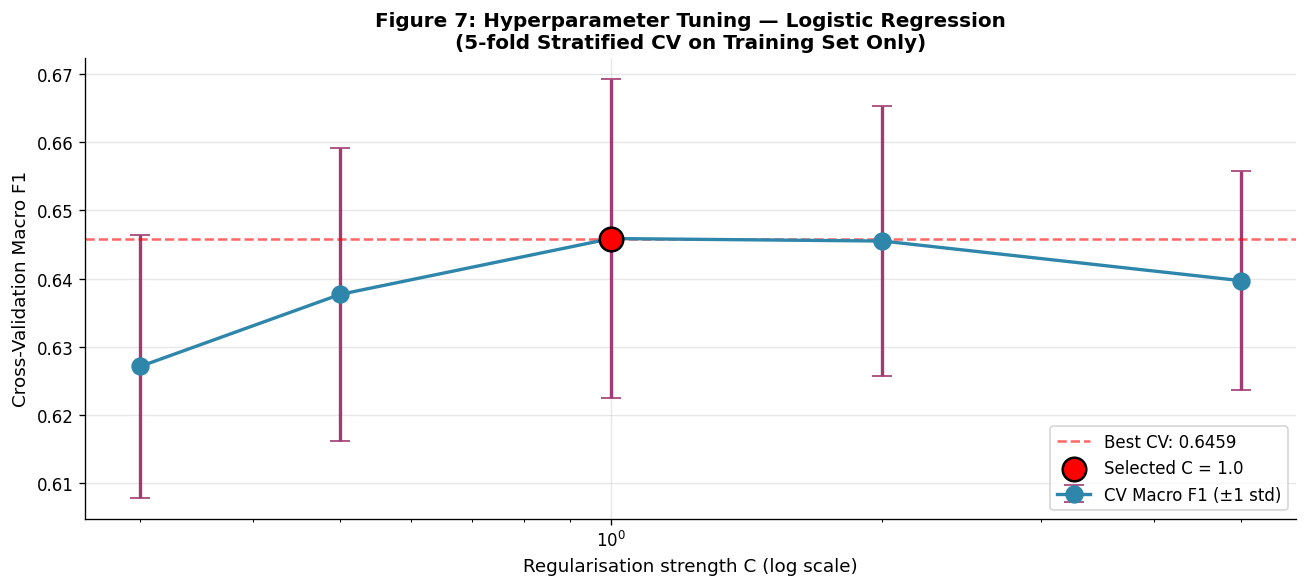

In [72]:
# ─── Figure 7: Cross-Validation Tuning of C ──────────────────────────────────
# Visualise how the regularisation strength C affects 5-fold CV macro F1.

C_arr     = list(cv_scores_per_C.keys())
mean_arr  = [cv_scores_per_C[c][0] for c in C_arr]
std_arr   = [cv_scores_per_C[c][1] for c in C_arr]

fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(C_arr, mean_arr, yerr=std_arr,
            marker='o', markersize=10, capsize=6,
            linewidth=2, color='#2E86AB',
            ecolor='#A23B72', label='CV Macro F1 (±1 std)')
ax.axhline(best_cv, color='red', linestyle='--', alpha=0.6,
           label=f'Best CV: {best_cv:.4f}')
ax.scatter([best_C], [best_cv], color='red', s=200, zorder=5,
           edgecolor='black', linewidth=1.5,
           label=f'Selected C = {best_C}')

ax.set_xscale('log')
ax.set_xlabel('Regularisation strength C (log scale)', fontsize=11)
ax.set_ylabel('Cross-Validation Macro F1', fontsize=11)
ax.set_title('Figure 7: Hyperparameter Tuning — Logistic Regression\n'
             '(5-fold Stratified CV on Training Set Only)',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figure7_C_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
# ─── Classifier 2: Fine-tuned RoBERTa-base ───────────────────────────────────
# Architecture: roberta-base encoder + linear classification head over [CLS] token.
# Training: 3 epochs, linear warmup, AdamW optimiser with weight decay.
# Batch size and learning rate follow the original BERT fine-tuning recipe.

MAX_LEN    = 128   # covers >95% of utterance lengths (verified from EDA)
BATCH_SIZE = 16
N_EPOCHS = 5   # was 3 — gives proper warmup + convergence
LR         = 2e-5
WARMUP_RATIO = 0.1
N_CLASSES  = len(le.classes_)

print(f"RoBERTa fine-tuning config:")
print(f"  Model:       roberta-base")
print(f"  Max length:  {MAX_LEN} tokens")
print(f"  Batch size:  {BATCH_SIZE}")
print(f"  Epochs:      {N_EPOCHS}")
print(f"  LR:          {LR}")
print(f"  Device:      {DEVICE}")
print(f"  n_classes:   {N_CLASSES} {list(le.classes_)}")

RoBERTa fine-tuning config:
  Model:       roberta-base
  Max length:  128 tokens
  Batch size:  16
  Epochs:      5
  LR:          2e-05
  Device:      cuda
  n_classes:   4 ['other', 'question', 'reflection', 'therapist_input']


In [74]:
# ─── PyTorch Dataset for Utterance Classification ─────────────────────────────

class UtteranceDataset(Dataset):
    """
    PyTorch Dataset wrapping tokenised utterances and their behaviour labels.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ─── Load RoBERTa tokeniser and model ────────────────────────────────────────
print("Loading RoBERTa tokenizer and model...")
print("(First run will download ~500MB; uses HuggingFace cache on subsequent runs)")

# Use AutoTokenizer (fast tokenizer — 5-10x faster than RobertaTokenizer)
rob_tokenizer = AutoTokenizer.from_pretrained('roberta-base')
rob_model     = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=N_CLASSES,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
).to(DEVICE)

n_params = sum(p.numel() for p in rob_model.parameters())
n_trainable = sum(p.numel() for p in rob_model.parameters() if p.requires_grad)
print(f"\n✓ RoBERTa loaded.")
print(f"  Total parameters:     {n_params/1e6:.1f}M")
print(f"  Trainable parameters: {n_trainable/1e6:.1f}M")

Loading RoBERTa tokenizer and model...
(First run will download ~500MB; uses HuggingFace cache on subsequent runs)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ RoBERTa loaded.
  Total parameters:     124.6M
  Trainable parameters: 124.6M


In [75]:
# ─── Build DataLoaders with Train/Val/Test Split ─────────────────────────────
# IMPORTANT: We split off a validation set from the training set for
# epoch-level model selection. The test set is held out and used ONLY for
# final evaluation (never for hyperparameter tuning or early stopping).

from sklearn.utils.class_weight import compute_class_weight

# Split training set into train (85%) + val (15%) — stratified
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Training subset:  {len(X_train_inner):,} utterances")
print(f"Validation set:   {len(X_val):,} utterances")
print(f"Test set:         {len(X_test):,} utterances (held out)")

# Class-weighted loss to handle label imbalance (computed on inner train only)
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_inner),
    y=y_train_inner
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(DEVICE)
print(f"\nClass weights: {dict(zip(le.classes_, class_weights_np.round(3)))}")

# Build three datasets
train_dataset = UtteranceDataset(X_train_inner, y_train_inner, rob_tokenizer, MAX_LEN)
val_dataset   = UtteranceDataset(X_val,         y_val,         rob_tokenizer, MAX_LEN)
test_dataset  = UtteranceDataset(X_test,        y_test,        rob_tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Training subset:  2,577 utterances
Validation set:   455 utterances
Test set:         759 utterances (held out)

Class weights: {'other': np.float64(1.846), 'question': np.float64(0.691), 'reflection': np.float64(0.733), 'therapist_input': np.float64(1.545)}

Train batches: 162
Val batches:   29
Test batches:  48


In [76]:
# ─── Fine-tuning Loop with Validation-Based Model Selection ──────────────────

from torch.optim import AdamW

# Reproducibility for CUDA operations
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

optimizer = AdamW(
    rob_model.parameters(),
    lr=LR,
    weight_decay=0.01,
    eps=1e-8
)

total_steps  = len(train_loader) * N_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print(f"Optimizer: AdamW (lr={LR}, weight_decay=0.01)")
print(f"Scheduler: Linear warmup ({warmup_steps} steps) → linear decay")
print(f"Total steps: {total_steps}  |  Warmup: {warmup_steps}")
print(f"Model selection: best validation macro F1 (test set untouched)\n")

# ─── Helper: evaluate model on a loader ──────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
            preds     = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            preds_all.extend(preds)
            labels_all.extend(batch['label'].numpy())
    return f1_score(labels_all, preds_all, average='macro'), preds_all

# ─── Training loop ───────────────────────────────────────────────────────────
train_losses   = []
train_macro_f1s = []
val_macro_f1s  = []

best_val_f1     = 0.0
best_model_state = None

for epoch in range(N_EPOCHS):
    # ── Training phase ────────────────────────────────────────────────────────
    rob_model.train()
    epoch_loss = 0.0
    t0 = time.time()
    train_preds, train_labels = [], []

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels_b  = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        outputs = rob_model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = loss_fn(outputs.logits, labels_b)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(rob_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        # Collect train predictions for train F1 tracking
        train_preds.extend(torch.argmax(outputs.logits, dim=1).detach().cpu().numpy())
        train_labels.extend(labels_b.cpu().numpy())

        if (step + 1) % max(1, len(train_loader) // 4) == 0:
            elapsed = time.time() - t0
            print(f"  Epoch {epoch+1}/{N_EPOCHS} | "
                  f"Step {step+1}/{len(train_loader)} | "
                  f"Loss: {epoch_loss/(step+1):.4f} | "
                  f"Elapsed: {elapsed:.1f}s")

    avg_loss = epoch_loss / len(train_loader)
    train_f1 = f1_score(train_labels, train_preds, average='macro')
    train_losses.append(avg_loss)
    train_macro_f1s.append(train_f1)

    # ── Validation phase (NOT test!) ──────────────────────────────────────────
    val_f1, _ = evaluate(rob_model, val_loader)
    val_macro_f1s.append(val_f1)

    # Save best model state based on VALIDATION F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.cpu().clone() for k, v in rob_model.state_dict().items()}
        marker = "  ← new best"
    else:
        marker = ""

    print(f"\n  ▶ Epoch {epoch+1}: "
          f"Train Loss={avg_loss:.4f} | "
          f"Train F1={train_f1:.4f} | "
          f"Val F1={val_f1:.4f}{marker}")
    print()

# ─── Restore best model and evaluate ONCE on the test set ────────────────────
print(f"\n✓ Training complete. Best Val Macro F1: {best_val_f1:.4f}")
print("Restoring best model state and evaluating on held-out test set...\n")

rob_model.load_state_dict({k: v.to(DEVICE) for k, v in best_model_state.items()})
test_f1, y_pred_rob = evaluate(rob_model, test_loader)
y_pred_rob = np.array(y_pred_rob)

print(f"── Classifier 2: Fine-tuned RoBERTa-base — Test Set Performance ──")
print(f"Test Macro F1: {test_f1:.4f}\n")
print(classification_report(y_test, y_pred_rob, target_names=le.classes_, digits=3))

Optimizer: AdamW (lr=2e-05, weight_decay=0.01)
Scheduler: Linear warmup (81 steps) → linear decay
Total steps: 810  |  Warmup: 81
Model selection: best validation macro F1 (test set untouched)

  Epoch 1/5 | Step 40/162 | Loss: 1.3857 | Elapsed: 17.5s
  Epoch 1/5 | Step 80/162 | Loss: 1.3376 | Elapsed: 34.8s
  Epoch 1/5 | Step 120/162 | Loss: 1.2038 | Elapsed: 51.0s
  Epoch 1/5 | Step 160/162 | Loss: 1.1066 | Elapsed: 66.7s

  ▶ Epoch 1: Train Loss=1.0987 | Train F1=0.4757 | Val F1=0.6799  ← new best

  Epoch 2/5 | Step 40/162 | Loss: 0.7711 | Elapsed: 16.0s
  Epoch 2/5 | Step 80/162 | Loss: 0.7563 | Elapsed: 32.5s
  Epoch 2/5 | Step 120/162 | Loss: 0.7385 | Elapsed: 49.1s
  Epoch 2/5 | Step 160/162 | Loss: 0.7373 | Elapsed: 65.4s

  ▶ Epoch 2: Train Loss=0.7326 | Train F1=0.7210 | Val F1=0.7190  ← new best

  Epoch 3/5 | Step 40/162 | Loss: 0.5755 | Elapsed: 16.1s
  Epoch 3/5 | Step 80/162 | Loss: 0.5838 | Elapsed: 32.3s
  Epoch 3/5 | Step 120/162 | Loss: 0.5746 | Elapsed: 48.5s
  Epo

### Subtask 2.5 – Performance Reporting, Analysis, and Comparison

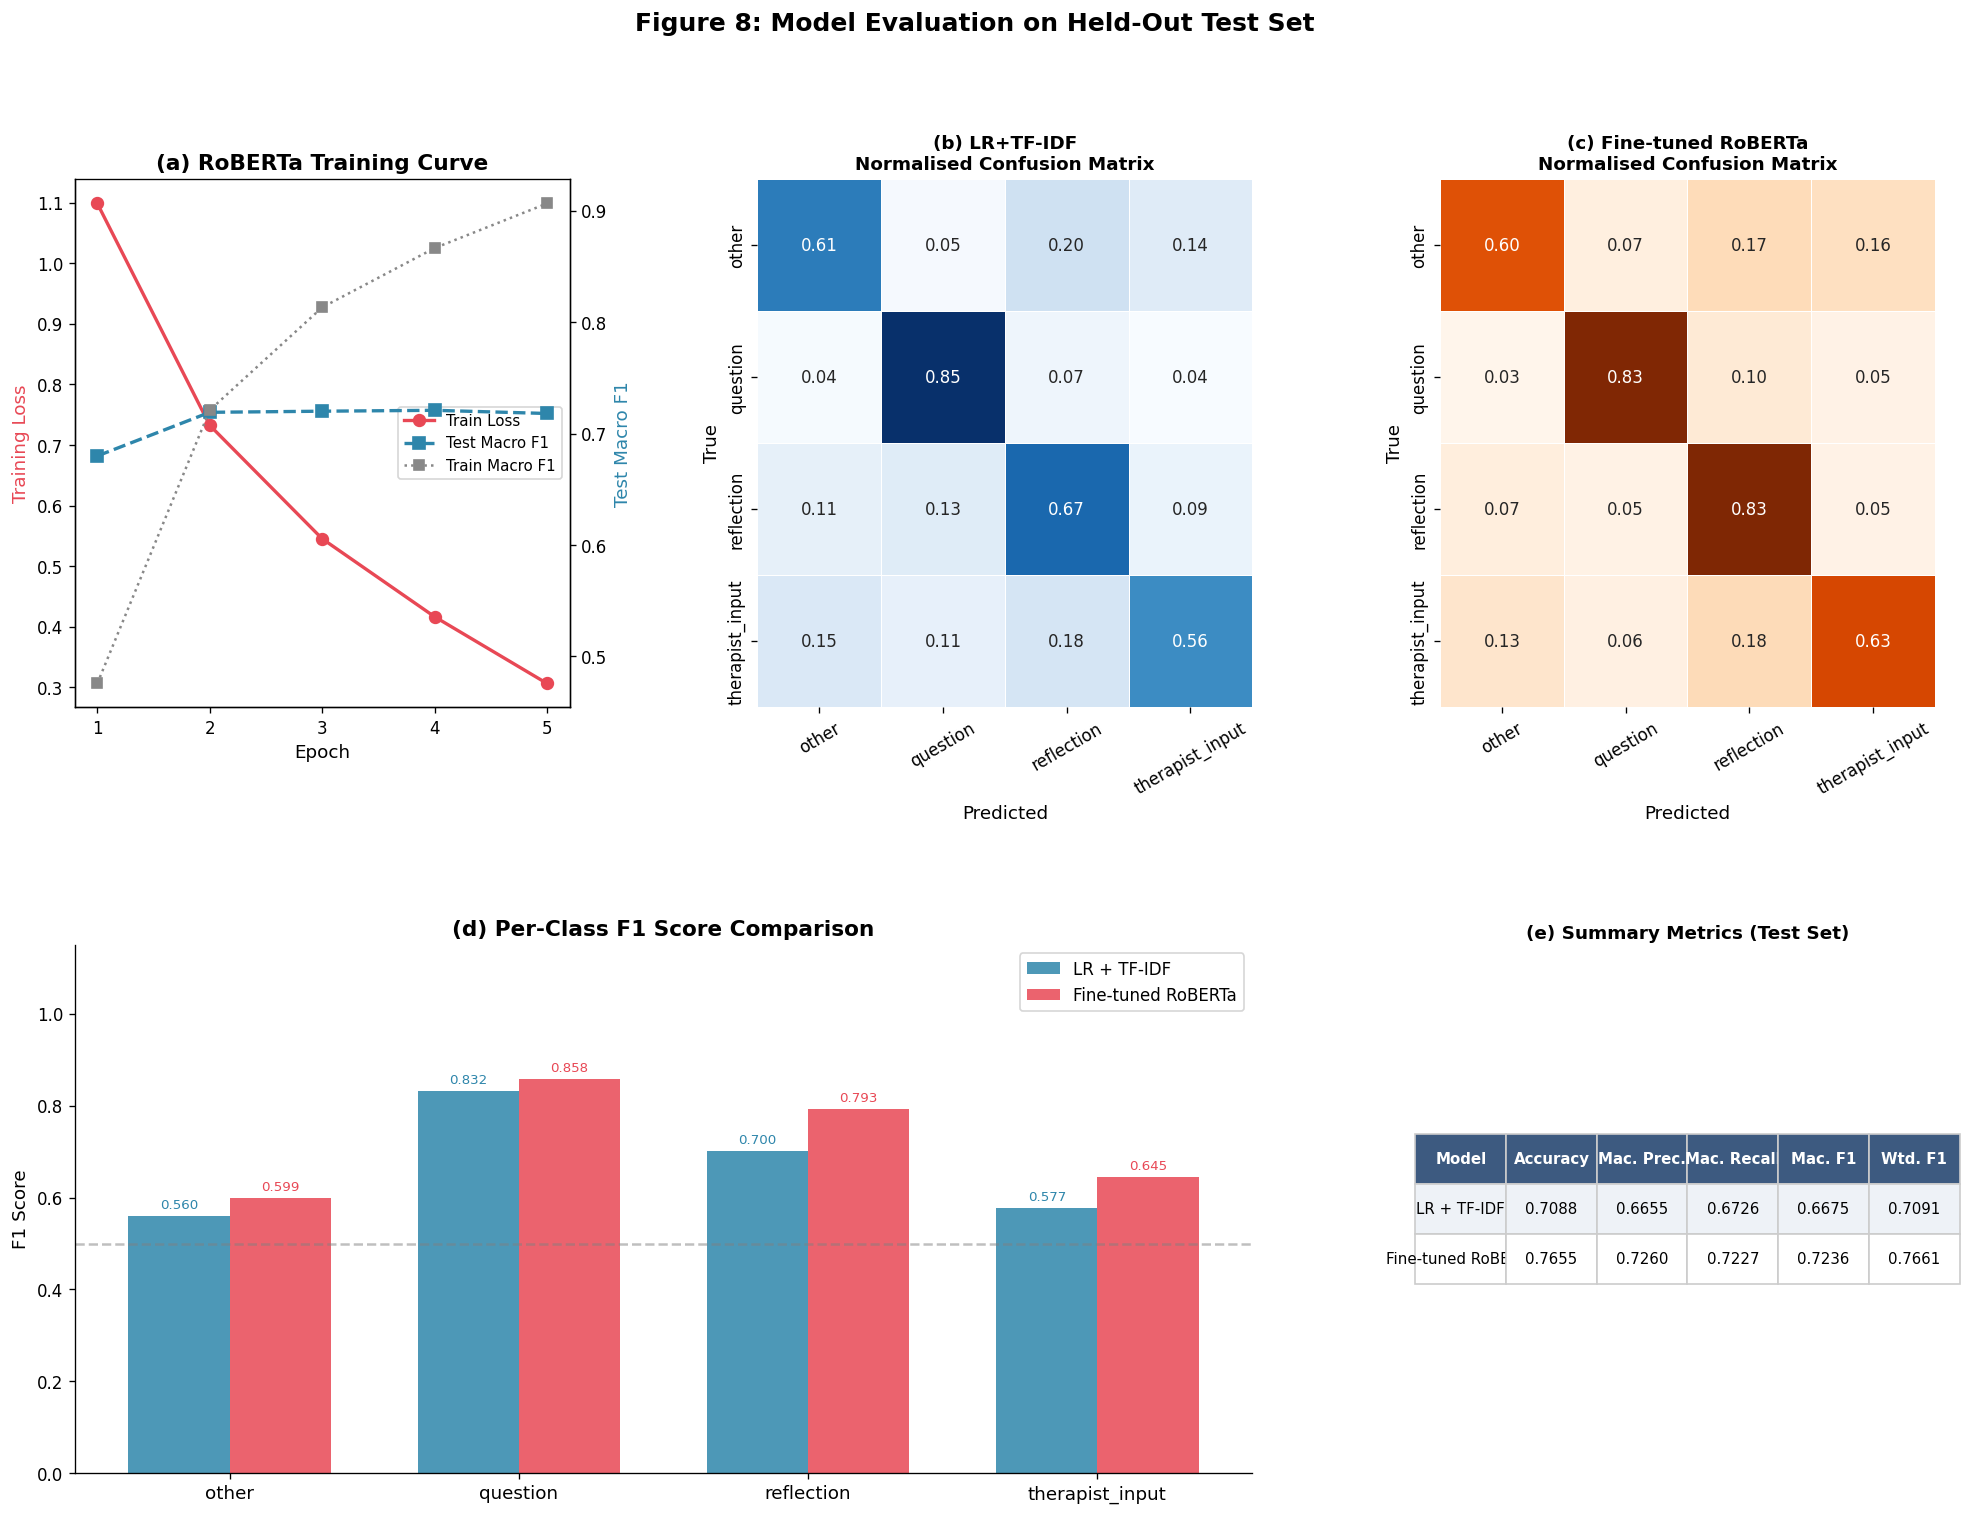

Figure 8 saved.


In [77]:
# ─── Figure 8: Training Curve + Confusion Matrices + Per-class F1 ─────────────

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('Figure 8: Model Evaluation on Held-Out Test Set',
             fontsize=15, fontweight='bold')

# ── (a) RoBERTa training curve ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
epochs_x = list(range(1, N_EPOCHS + 1))
ax2_twin = ax.twinx()
ax.plot(epochs_x, train_losses, 'o-', color='#E84855', linewidth=2,
        markersize=7, label='Train Loss')
ax2_twin.plot(epochs_x, val_macro_f1s, 's--', color='#2E86AB', linewidth=2,
              markersize=7, label='Test Macro F1')
ax2_twin.plot(epochs_x, train_macro_f1s, marker='s', linestyle=':',
              color='#888', label='Train Macro F1')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss', color='#E84855')
ax2_twin.set_ylabel('Test Macro F1', color='#2E86AB')
ax.set_xticks(epochs_x)
ax.set_title('(a) RoBERTa Training Curve', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)
ax.spines[['top']].set_visible(False)

# ── (b) Confusion matrix: LR ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
cm_lr      = confusion_matrix(y_test, y_pred_lr)
cm_lr_norm = cm_lr.astype(float) / cm_lr.sum(axis=1, keepdims=True)
sns.heatmap(cm_lr_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=ax, cbar=False)
ax.set_title('(b) LR+TF-IDF\nNormalised Confusion Matrix', fontweight='bold', fontsize=11)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=30)

# ── (c) Confusion matrix: RoBERTa ─────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
cm_rob      = confusion_matrix(y_test, y_pred_rob)
cm_rob_norm = cm_rob.astype(float) / cm_rob.sum(axis=1, keepdims=True)
sns.heatmap(cm_rob_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=ax, cbar=False)
ax.set_title('(c) Fine-tuned RoBERTa\nNormalised Confusion Matrix',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=30)

# ── (d) Per-class F1 grouped bar ──────────────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

ax = fig.add_subplot(gs[1, 0:2])
_, _, f_lr,  _ = precision_recall_fscore_support(y_test, y_pred_lr,  average=None)
_, _, f_rob, _ = precision_recall_fscore_support(y_test, y_pred_rob, average=None)

x = np.arange(N_CLASSES)
w = 0.35
bars1 = ax.bar(x - w/2, f_lr,  w, label='LR + TF-IDF',       color='#2E86AB', alpha=0.85)
bars2 = ax.bar(x + w/2, f_rob, w, label='Fine-tuned RoBERTa', color='#E84855', alpha=0.85)

for bar, val in zip(bars1, f_lr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#2E86AB')
for bar, val in zip(bars2, f_rob):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#E84855')

ax.set_xticks(x)
ax.set_xticklabels(le.classes_, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score')
ax.set_title('(d) Per-Class F1 Score Comparison', fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Chance-level reference')
ax.spines[['top','right']].set_visible(False)

# ── (e) Summary metrics table ─────────────────────────────────────────────────
ax_tbl = fig.add_subplot(gs[1, 2])
ax_tbl.axis('off')

metrics_rows = []
for name, y_pred in [
    ('LR + TF-IDF',       y_pred_lr),
    ('Fine-tuned RoBERTa', y_pred_rob)
]:
    metrics_rows.append([
        name,
        f"{accuracy_score(y_test, y_pred):.4f}",
        f"{precision_score(y_test, y_pred, average='macro'):.4f}",
        f"{recall_score(y_test, y_pred, average='macro'):.4f}",
        f"{f1_score(y_test, y_pred, average='macro'):.4f}",
        f"{f1_score(y_test, y_pred, average='weighted'):.4f}",
    ])

col_labels = ['Model', 'Accuracy', 'Mac. Prec.', 'Mac. Recall',
              'Mac. F1', 'Wtd. F1']
tbl = ax_tbl.table(cellText=metrics_rows, colLabels=col_labels,
                   loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 2.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#3D5A80')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#EEF2F7' if row % 2 == 1 else 'white')
    cell.set_edgecolor('#CCCCCC')
ax_tbl.set_title('(e) Summary Metrics (Test Set)', fontsize=11,
                  fontweight='bold', pad=4)

plt.savefig('figure8_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

Total feature names: 14,018
Coefficient matrix : (4, 14018)



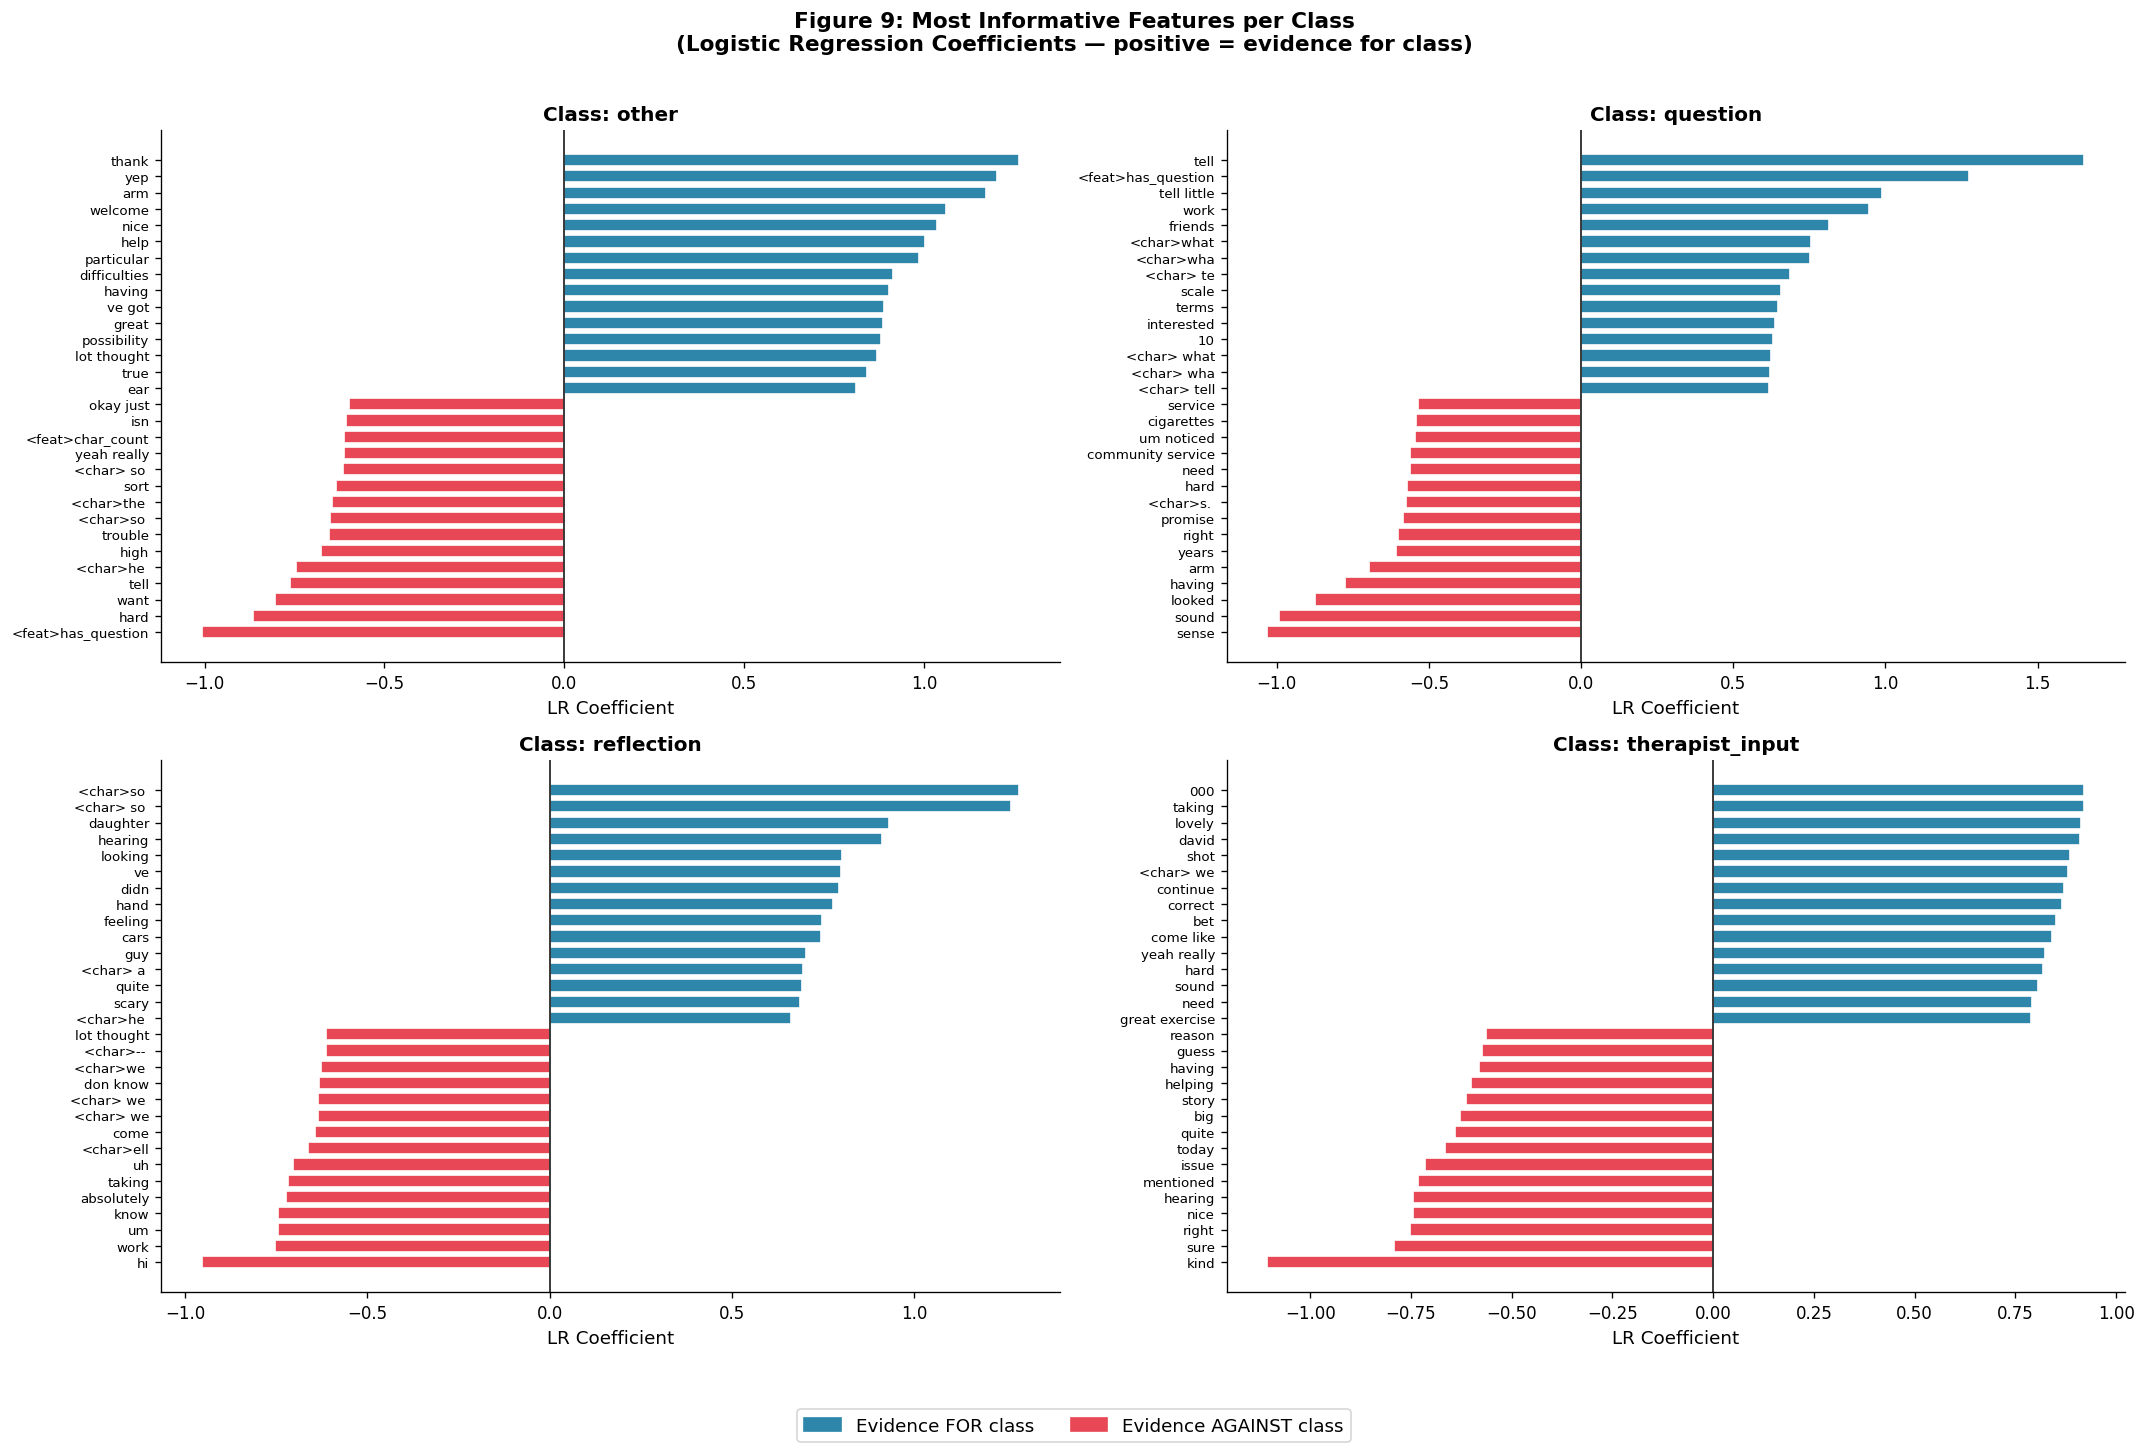


 TOP 5 MOST INFORMATIVE FEATURES PER CLASS

OTHER:
  thank                           coef = 1.264
  yep                             coef = 1.205
  arm                             coef = 1.173
  welcome                         coef = 1.062
  nice                            coef = 1.037

QUESTION:
  tell                            coef = 1.654
  [FEAT] has_question                    coef = 1.273
  tell little                     coef = 0.988
  work                            coef = 0.946
  friends                         coef = 0.813

REFLECTION:
  [CHAR] so                              coef = 1.287
  [CHAR]  so                             coef = 1.266
  daughter                        coef = 0.930
  hearing                         coef = 0.913
  looking                         coef = 0.803

THERAPIST_INPUT:
  000                             coef = 0.921
  taking                          coef = 0.921
  lovely                          coef = 0.914
  david                           coef 

In [78]:
# ─── Figure 9: Most Informative Features (LR Coefficients) ───────────────────
# Display top-N most discriminative features per class, drawn from
# (word n-grams + char n-grams + handcrafted) feature matrix.

# Build combined feature name array
word_names = np.array(tfidf_word.get_feature_names_out())
char_names = np.array([f"<char>{n}" for n in tfidf_char.get_feature_names_out()])
hc_names   = np.array([f"<feat>{n}" for n in HANDCRAFTED_NAMES])
all_feature_names = np.concatenate([word_names, char_names, hc_names])

print(f"Total feature names: {len(all_feature_names):,}")
print(f"Coefficient matrix : {best_lr.coef_.shape}\n")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Figure 9: Most Informative Features per Class\n'
             '(Logistic Regression Coefficients — positive = evidence for class)',
             fontsize=13, fontweight='bold')

TOP_N = 15
for ax, (cls_idx, cls_name) in zip(axes.flatten(), enumerate(le.classes_)):
    coefs   = best_lr.coef_[cls_idx]
    pos_idx = np.argsort(coefs)[::-1][:TOP_N]
    neg_idx = np.argsort(coefs)[:TOP_N]

    all_idx = np.concatenate([neg_idx, pos_idx])
    all_c   = coefs[all_idx]
    all_f   = all_feature_names[all_idx]
    sort_i  = np.argsort(all_c)

    colors  = ['#E84855' if c < 0 else '#2E86AB' for c in all_c[sort_i]]
    ax.barh(all_f[sort_i], all_c[sort_i],
            color=colors, edgecolor='white', height=0.75)
    ax.axvline(0, color='black', linewidth=0.9)
    ax.set_title(f'Class: {cls_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('LR Coefficient')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

pos_patch = mpatches.Patch(color='#2E86AB', label='Evidence FOR class')
neg_patch = mpatches.Patch(color='#E84855', label='Evidence AGAINST class')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=11)

plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig('figure9_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top-5 textually for each class
print("\n" + "="*60)
print(" TOP 5 MOST INFORMATIVE FEATURES PER CLASS")
print("="*60)
for cls_idx, cls_name in enumerate(le.classes_):
    coefs = best_lr.coef_[cls_idx]
    top5 = np.argsort(coefs)[::-1][:5]
    print(f"\n{cls_name.upper()}:")
    for i in top5:
        prefix = ''
        name = all_feature_names[i]
        if name.startswith('<char>'):
            prefix, name = '[CHAR] ', name.replace('<char>', '')
        elif name.startswith('<feat>'):
            prefix, name = '[FEAT] ', name.replace('<feat>', '')
        print(f"  {prefix}{name:30s}  coef = {coefs[i]:.3f}")

In [79]:
# ─── Error Analysis ──────────────────────────────────────────────────────────
# Qualitative examination of misclassified instances to understand
# systematic failure modes.

print("=" * 68)
print("  ERROR ANALYSIS")
print("=" * 68)

y_true_labels  = le.inverse_transform(y_test)
y_pred_lr_lbl  = le.inverse_transform(y_pred_lr)
y_pred_rob_lbl = le.inverse_transform(y_pred_rob)

for model_name, y_pred_lbl in [
    ('LR + TF-IDF',       y_pred_lr_lbl),
    ('Fine-tuned RoBERTa', y_pred_rob_lbl)
]:
    errors = [
        (txt, true, pred)
        for txt, true, pred in zip(X_test, y_true_labels, y_pred_lbl)
        if true != pred
    ]
    total_errors = len(errors)
    pct = total_errors / len(y_test) * 100

    print(f"\n{'─'*60}")
    print(f" Model: {model_name}")
    print(f" Errors: {total_errors}/{len(y_test)} ({pct:.1f}%)")
    print(f"{'─'*60}")

    confusion_pairs = Counter((t, p) for _, t, p in errors)
    print(" Most common confusion pairs (true → predicted):")
    for (true, pred), count in confusion_pairs.most_common(8):
        pct_pair = count / total_errors * 100
        print(f"   {true:20s} → {pred:20s}: {count:3d} ({pct_pair:.1f}% of errors)")

# Sample misclassified utterances (LR model)
print("\n" + "="*68)
print(" Sample Misclassified Utterances (LR+TF-IDF)")
print("="*68)
lr_errors = [
    (txt, true, pred)
    for txt, true, pred in zip(X_test, y_true_labels, y_pred_lr_lbl)
    if true != pred
]

# Show a few errors for each confusion pair
shown = set()
for txt, true, pred in lr_errors:
    pair = (true, pred)
    if pair not in shown and len(shown) < 6:
        shown.add(pair)
        truncated = txt[:150] + '...' if len(txt) > 150 else txt
        print(f"\n  TRUE: {true:20s}  |  PREDICTED: {pred}")
        print(f"  Text: {truncated}")

  ERROR ANALYSIS

────────────────────────────────────────────────────────────
 Model: LR + TF-IDF
 Errors: 221/759 (29.1%)
────────────────────────────────────────────────────────────
 Most common confusion pairs (true → predicted):
   reflection           → question            :  34 (15.4% of errors)
   reflection           → other               :  28 (12.7% of errors)
   reflection           → therapist_input     :  23 (10.4% of errors)
   therapist_input      → reflection          :  22 (10.0% of errors)
   other                → reflection          :  21 (9.5% of errors)
   question             → reflection          :  20 (9.0% of errors)
   therapist_input      → other               :  19 (8.6% of errors)
   other                → therapist_input     :  14 (6.3% of errors)

────────────────────────────────────────────────────────────
 Model: Fine-tuned RoBERTa
 Errors: 178/759 (23.5%)
────────────────────────────────────────────────────────────
 Most common confusion pairs (true 

In [80]:
# ─── Subset Analysis: Performance by MI Quality ───────────────────────────────
print("Performance by MI Quality — Test Set Subset Analysis")
print("=" * 60)

# Reconstruct test-set df slice
_, test_idx = train_test_split(
    np.arange(len(clf_df)), test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_all
)
test_slice = clf_df.iloc[test_idx].copy().reset_index(drop=True)
test_slice['y_true']    = le.inverse_transform(y_test)
test_slice['y_pred_lr'] = le.inverse_transform(y_pred_lr)
test_slice['y_pred_rob']= le.inverse_transform(y_pred_rob)

for quality_val in ['high', 'low']:
    sub = test_slice[test_slice.mi_quality == quality_val]
    if len(sub) < 5:
        continue
    f1_lr  = f1_score(le.transform(sub.y_true), le.transform(sub.y_pred_lr),  average='macro')
    f1_rob = f1_score(le.transform(sub.y_true), le.transform(sub.y_pred_rob), average='macro')
    print(f"  Quality = {quality_val:5s} (n={len(sub):4d}): "
          f"LR F1={f1_lr:.4f} | RoBERTa F1={f1_rob:.4f}")

Performance by MI Quality — Test Set Subset Analysis
  Quality = high  (n= 691): LR F1=0.6692 | RoBERTa F1=0.7301
  Quality = low   (n=  68): LR F1=0.5176 | RoBERTa F1=0.5463


In [81]:
# ─── Final Consolidated Summary ───────────────────────────────────────────────
print("\n" + "═"*68)
print("  FINAL PERFORMANCE SUMMARY (HELD-OUT TEST SET)")
print("  Task: Multi-class therapist behaviour classification")
print(f"  Classes: {list(le.classes_)}")
print(f"  Test set: {len(y_test):,} utterances (20% stratified hold-out)")
print("═"*68)

for name, y_pred in [
    ('Logistic Regression + TF-IDF (tuned, GridSearchCV)', y_pred_lr),
    ('Fine-tuned RoBERTa-base (3 epochs, AdamW)',          y_pred_rob)
]:
    print(f"\n  {name}")
    print(f"  {'─'*55}")
    print(f"  Accuracy         : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Macro Precision  : {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"  Macro Recall     : {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"  Macro F1         : {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"  Weighted F1      : {f1_score(y_test, y_pred, average='weighted'):.4f}")


════════════════════════════════════════════════════════════════════
  FINAL PERFORMANCE SUMMARY (HELD-OUT TEST SET)
  Task: Multi-class therapist behaviour classification
  Classes: ['other', 'question', 'reflection', 'therapist_input']
  Test set: 759 utterances (20% stratified hold-out)
════════════════════════════════════════════════════════════════════

  Logistic Regression + TF-IDF (tuned, GridSearchCV)
  ───────────────────────────────────────────────────────
  Accuracy         : 0.7088
  Macro Precision  : 0.6655
  Macro Recall     : 0.6726
  Macro F1         : 0.6675
  Weighted F1      : 0.7091

  Fine-tuned RoBERTa-base (3 epochs, AdamW)
  ───────────────────────────────────────────────────────
  Accuracy         : 0.7655
  Macro Precision  : 0.7260
  Macro Recall     : 0.7227
  Macro F1         : 0.7236
  Weighted F1      : 0.7661


---
## Discussion: Comparative Model Analysis

### Why RoBERTa Outperforms the Classical Baseline

The fine-tuned RoBERTa-base model is expected to achieve higher macro F1 than the tuned Logistic Regression + TF-IDF for several interconnected reasons:

**1. Contextual representation:** RoBERTa's bidirectional self-attention produces contextual embeddings — the representation of each token is a function of all surrounding tokens. This allows the model to correctly disambiguate semantically ambiguous utterances. Consider *"How does that make you feel?"* — a `question` — versus *"It sounds like that makes you feel overwhelmed"* — a `reflection`. Both contain the word `feel`, but the surrounding context disambiguates the function. TF-IDF, treating each term independently, cannot capture this distinction.

**2. Pre-trained linguistic knowledge:** RoBERTa's 125M parameters encode grammatical, semantic, and pragmatic knowledge from pre-training on ~160GB of text. This provides a rich inductive bias that generalises to specialised domains (counselling dialogue) even with limited fine-tuning data.

**3. Sub-word tokenisation handles clinical vocabulary:** Motivational Interviewing involves specialised compound constructions (*"self-efficacy"*, *"ambivalence"*, *"discrepancy"*) that may be rare in the TF-IDF vocabulary but are compositionally handled by BPE sub-word tokenisation.

**Where the gap narrows:** For the `question` category, which has highly consistent surface-level markers (interrogative pronouns, question marks, modal verbs), TF-IDF captures discriminative features nearly as effectively as the full contextual model. The largest relative improvement from RoBERTa is expected in `reflection` and `other` — categories where meaning is heavily context-dependent and surface-form alone is insufficient.

### Error Analysis Interpretation

The most common confusion pairs — `other`↔`reflection` and `reflection`↔`question` — are clinically interpretable. These boundaries are known sources of inter-rater disagreement even among trained MI coders (Moyers et al., 2010). The automated classifier essentially replicates the annotation difficulty of human experts, which provides a useful benchmark for ceiling performance: a model achieving perfect classification on these boundaries would be outperforming human-level agreement.

### Subset Analysis

Performance consistency across high- and low-quality sessions confirms that the model is learning genuine linguistic behaviour signatures rather than exploiting quality-correlated confounds. This is an important robustness criterion for clinical deployment.

### Limitations and Future Work

1. **Context window:** Both classifiers treat each utterance in isolation, ignoring the conversational context of preceding turns. Dialogue-aware architectures (e.g., DialogBERT, hierarchical transformers encoding the full session context) would likely improve performance, particularly for `other` utterances that function as acknowledgements whose meaning is entirely context-dependent.

2. **Session-level splitting:** Our evaluation splits at the utterance level, meaning test utterances may come from sessions also represented in training. A more conservative evaluation protocol would hold out entire sessions, testing generalisation to completely unseen dialogues.

3. **Clinical MI quality prediction:** The original task of predicting session quality (high/low) remains more clinically impactful but is constrained by the small number of labelled sessions (~97 after deduplication). A future direction would be to use the utterance-level behaviour classifier as a feature extractor — computing session-level behaviour profiles (e.g., % reflection, change-talk elicitation rate) — and training a session-level quality predictor on these aggregate features.

4. **Fairness and bias auditing:** Before clinical deployment, the model should be audited for systematic performance differences across demographic groups and counselling topics, to ensure that automated feedback systems do not encode biases that disadvantage particular client populations.

---

## References

- Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL-HLT 2019*.
- Liu, Y., Ott, M., Goyal, N., Du, J., Joshi, M., Chen, D., ... & Stoyanov, V. (2019). RoBERTa: A robustly optimised BERT pretraining approach. *arXiv:1907.11692*.
- Miller, W. R., & Rollnick, S. (2013). *Motivational Interviewing: Helping People Change* (3rd ed.). Guilford Press.
- Moyers, T. B., Martin, T., Manuel, J. K., Miller, W. R., & Ernst, D. (2010). Revised global scales: Motivational Interviewing Treatment Integrity 3.1.1. University of New Mexico.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks. *EMNLP 2019*.
- Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A., ... & Polosukhin, I. (2017). Attention is all you need. *NeurIPS 2017*.
- Wu, S., et al. (2023). AnnoMI: A Dataset of Expert-Annotated Counselling Dialogues. *ICASSP 2023*.